In [91]:
import pandas as pd
import numpy as np
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress, shapiro, ks_2samp, kruskal, chi2_contingency
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_curve, auc
import diptest


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [ ]:
plt.rcParams.update({'font.size': 14})

In [3]:
def load_aligned_data(uniprot_ids, pipeline_dir, rocklin_dir=None):
    pipeline_data = {}
    rocklin_data = {}

    for uniprot_id in uniprot_ids:
        #  pipeline 
        pipe_file = os.path.join(pipeline_dir, f"pipeline_{uniprot_id}.csv")
        if os.path.exists(pipe_file):
            df = pd.read_csv(pipe_file)

            df["res"] = df["res"].astype(int)

            # build variant column
            df["variant_rebased"] = (df["mut_from_rebased"].astype(str) + df["res"].astype(str) + df["mut_to"].astype(str))

            df["uniprot_id"] = uniprot_id
            pipeline_data[uniprot_id] = df

        #  rocklin 
        rock_file = os.path.join(rocklin_dir, f"Rocklin2_{uniprot_id}.csv")
        if os.path.exists(rock_file):
            df = pd.read_csv(rock_file)

            df["res"] = df["res"].astype(int)
            df["variant_rebased"] = (df["mut_from_rebased"].astype(str) + df["res"].astype(str) + df["mut_to"].astype(str))

    
            df["uniprot_id"] = uniprot_id

            rocklin_data[uniprot_id] = {}
            for pdb_id, subdf in df.groupby("pdb_id"):
                rocklin_data[uniprot_id][pdb_id] = subdf.reset_index(drop=True)
                
            rocklin_data[uniprot_id] = df

    return pipeline_data, rocklin_data


In [4]:
with open("../Output/pdb_to_uniprot2.json") as f:
    pdb_to_uniprot2 = json.load(f)

uniprot_ids = list(pdb_to_uniprot2.values())

In [5]:
pipeline_dir = "../Output/Aligned_dfs"
rocklin_dir  = "../Output/Aligned_dfs"

pipeline_data, Rocklin2_data = load_aligned_data(
    uniprot_ids,
    pipeline_dir,
    rocklin_dir,
)


In [9]:
# Coverage snapshot capturing raw structure & residue counts for every candidate protein

raw_coverage_snapshot = []
for uid in uniprot_ids:
    pdf = pipeline_data.get(uid)
    rdf = Rocklin2_data.get(uid)

    n_pipeline_structures = pdf["pdb_id"].nunique() if pdf is not None and not pdf.empty else 0

    if rdf is not None and not rdf.empty:
        rocklin_residue_counts = rdf.groupby("pdb_id")["res"].nunique()
        n_rocklin_structures_total = rocklin_residue_counts.shape[0]
        n_rocklin_structures_passing_residue_filter = int((rocklin_residue_counts > 6).sum())
        median_residues_per_rocklin_structure = rocklin_residue_counts.median()
    else:
        n_rocklin_structures_total = 0
        n_rocklin_structures_passing_residue_filter = 0
        median_residues_per_rocklin_structure = np.nan

    raw_coverage_snapshot.append({
        "uniprot_id": uid,
        "n_pipeline_structures_available": n_pipeline_structures,
        "n_rocklin_structures_total": n_rocklin_structures_total,
        "n_rocklin_structures_passing_gt6_residue_filter": n_rocklin_structures_passing_residue_filter,
        "median_residues_per_rocklin_structure": median_residues_per_rocklin_structure,
    })

raw_coverage_snapshot_df = pd.DataFrame(raw_coverage_snapshot)
raw_coverage_snapshot_df.head()


,uniprot_id,n_pipeline_structures_available,n_rocklin_structures_total,n_rocklin_structures_passing_gt6_residue_filter,median_residues_per_rocklin_structure
0,P06241,45,1,1,58.0
1,P05766,1,1,1,63.0
2,P0A6D0,4,1,1,69.0
3,P07751,53,12,12,54.5
4,P32081,12,1,1,67.0


In [10]:
# Take the mean ddg to average across homomeric chains in pipeline structures

pipeline_data_meanhomo = defaultdict(dict)

for uniprot_id, df in pipeline_data.items():
    # Group by pdb_id + variant to take mean ddg
    for pdb_id, pdb_df in df.groupby("pdb_id"):
        mean_df = (
            pdb_df.groupby(["uniprot_id", "pdb_id", "variant_rebased"], as_index=False)
                  .agg({
                      "ddg_rebased": "mean",
                      "mut_from_rebased": "first",
                      "mut_to": "first",
                      "res": "first",
                  })
        )
        pipeline_data_meanhomo[uniprot_id][pdb_id] = mean_df


In [11]:
# Stash an unfiltered copy of Rocklin2_data


Rocklin2_data_unfiltered = {uid: df.copy() for uid, df in Rocklin2_data.items()}

In [12]:
# Remove Rocklin pdb_id if only a handful of residues (i.e. if <=6 residues)

for uniprot_id, df in Rocklin2_data.items():
    if df.empty:
        continue

    filtered_list = []
    for pdb_id, df_pdb in df.groupby("pdb_id"):
        if df_pdb["res"].nunique() > 6:
            filtered_list.append(df_pdb.copy())

        else:
            filtered_list.append(pd.DataFrame(columns=df.columns))

    Rocklin2_data[uniprot_id] = pd.concat(filtered_list, ignore_index=True)



C:\Users\zcemcel\AppData\Local\Temp\ipykernel_27780\3978587520.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Rocklin2_data[uniprot_id] = pd.concat(filtered_list, ignore_index=True)
C:\Users\zcemcel\AppData\Local\Temp\ipykernel_27780\3978587520.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Rocklin2_data[uniprot_id] = pd.concat(filtered_list, ignore_index=True)


In [13]:
# Take the mean of Rocklin structures with multiple estimates e.g. v2 or some Rocklin structures have versions with different aa substitutions 

Rocklin2_data_mean = {}

for uniprot_id, df in Rocklin2_data.items():
    if df is None or df.empty:
        continue

    Rocklin2_data_mean[uniprot_id] = {}

    # Take mean of ddg_rebased
    grouped = df.groupby(["uniprot_id", "pdb_id", "variant_rebased"], as_index=False)["ddg_rebased"].mean()
    grouped = grouped.rename(columns={"ddg_rebased": "ddg_rebased_rocklin"})

    # Split by pdb_id into nested dict
    for pdb_id, subdf in grouped.groupby("pdb_id"):
        Rocklin2_data_mean[uniprot_id][pdb_id] = subdf.reset_index(drop=True)


In [14]:
# Merge the datasets
# Nested dict
variant_data = defaultdict(lambda: defaultdict(list))

for uniprot_id, pipeline_pdb_dict in pipeline_data_meanhomo.items():

    # Skip if no Rocklin2 data
    rocklin_pdb_dict = Rocklin2_data_mean.get(uniprot_id)
    if not rocklin_pdb_dict:
        continue

    # Loop over Rocklin PDBs
    for rocklin_pdb_id, rocklin_df in rocklin_pdb_dict.items():

        # Loop over pipeline PDBs
        for pipeline_pdb_id, pipeline_df in pipeline_pdb_dict.items():

            df = pipeline_df.copy()

            # Merge on variant
            merged_df = df.merge(
                rocklin_df,
                on=["uniprot_id", "variant_rebased"],
                how="inner",
                suffixes=("_pipeline", "_rocklin")
            )

            # Append to list for this Rocklin PDB
            if not merged_df.empty:
                variant_data[uniprot_id][rocklin_pdb_id].append(merged_df)


In [15]:
#Total unique variants across everything
all_variants = set()
for uniprot_id, rocklin_dict in variant_data.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():
        for df in df_list:
            all_variants.update(df["variant_rebased"].unique())

print(f"Total unique variants across all proteins: {len(all_variants)}")


Total unique variants across all proteins: 89781


### Correlation analysis
(median aggregated if >5 structures)

In [25]:
# Calculate raw correlations

correlations = []

for uniprot_id, rocklin_dict in variant_data.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():
        # Skip if there are no DataFrames
        if len(df_list) == 0:
            continue

        # Combine all pipeline PDBs for this Rocklin PDB
        combined_df = pd.concat(df_list, ignore_index=True)

        # Skip if not enough points
        if combined_df.shape[0] < 2:
            continue

        # Pearson correlation
        r, pval = pearsonr(combined_df["ddg_rebased"], -combined_df["ddg_rebased_rocklin"]) # Negate Rocklin DDG folding energies to match misfolding energy convention of pipeline 

        # Number of pipeline structures contributing
        n_structures = len(df_list)

        # Store results
        correlations.append({
            "uniprot_id": uniprot_id,
            "rocklin_pdb_id": rocklin_pdb_id,
            "n_structures": n_structures,
            "pearson_r": r,
            "p_value": pval
        })

# Convert to DataFrame
correlation_df = pd.DataFrame(correlations)

In [26]:
correlation_df.sort_values(by="n_structures", ascending=False, inplace=True)

correlation_df


,uniprot_id,rocklin_pdb_id,n_structures,pearson_r,p_value
33,Q13526,2KCF,81,0.338016,0.000000e+00
32,Q13526,1I6C,81,0.469208,0.000000e+00
35,Q13526,2M8J,81,0.364322,0.000000e+00
34,Q13526,2M8I,81,0.419689,0.000000e+00
53,P00523,1SRM,65,0.405206,0.000000e+00
54,P00523,5ECA,65,0.354168,0.000000e+00
11,P07751,2KR3,48,0.405876,0.000000e+00
13,P07751,2LJ3,48,0.440282,0.000000e+00
3,P07751,1BK2,48,0.413180,0.000000e+00
4,P07751,1E6H,48,0.412467,0.000000e+00


In [27]:
# median-aggregated pipeline energies 
variant_median_data = defaultdict(dict)

for uniprot_id, rocklin_dict in variant_data.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():

        # Skip if nothing left after empty removal
        if not df_list:
            continue

        # Concatenate all pipeline DataFrames for this Rocklin structure
        all_df = pd.concat(df_list, ignore_index=True)

        # Aggregate per variant
        median_df = (
            all_df
            .groupby("variant_rebased", as_index=False)
            .agg(
                ddg_rebased_median=("ddg_rebased", "median"),
                n_pipeline=("ddg_rebased", "count"),
                ddg_rebased_rocklin=("ddg_rebased_rocklin", "mean"),
            )
        )

        # Add identifiers
        median_df["uniprot_id"] = uniprot_id
        median_df["rocklin_pdb_id"] = rocklin_pdb_id

        # Reorder columns (nice + explicit)
        median_df = median_df[
            [
                "uniprot_id",
                "rocklin_pdb_id",
                "variant_rebased",
                "ddg_rebased_median",
                "ddg_rebased_rocklin",
                "n_pipeline",
            ]
        ]

        # Store
        variant_median_data[uniprot_id][rocklin_pdb_id] = median_df


In [28]:
correlations_medians = []

for uniprot_id, rocklin_dict in variant_median_data.items():
    for rocklin_pdb_id, df in rocklin_dict.items():

        # Skip if not enough variants
        if df.shape[0] < 2:
            continue

        # Pearson correlation on MEDIAN pipeline ddG
        r, pval = pearsonr(
            df["ddg_rebased_median"],
            -df["ddg_rebased_rocklin"]
        )

        correlations_medians.append({
            "uniprot_id": uniprot_id,
            "rocklin_pdb_id": rocklin_pdb_id,
            "n_variants": df.shape[0],
            "n_structures": df["n_pipeline"].median(),  
            "pearson_r": r,
            "p_value": pval
        })

# Convert to DataFrame
correlation_medians_df = pd.DataFrame(correlations_medians)

In [29]:
correlation_medians_df.sort_values(by="n_structures", ascending=False, inplace=True)
correlation_medians_df

,uniprot_id,rocklin_pdb_id,n_variants,n_structures,pearson_r,p_value
33,Q13526,2KCF,230,75.0,0.418033,3.831995e-11
32,Q13526,1I6C,368,74.0,0.643122,2.446998e-44
34,Q13526,2M8I,325,74.0,0.564698,9.069156e-29
35,Q13526,2M8J,209,70.0,0.527397,2.319894e-16
53,P00523,1SRM,1045,65.0,0.602950,1.883719e-104
54,P00523,5ECA,1022,65.0,0.533496,3.046578e-76
12,P07751,2KXD,731,48.0,0.550645,3.458867e-59
11,P07751,2KR3,787,48.0,0.566786,4.435427e-68
8,P07751,1TUC,810,48.0,0.432304,3.244075e-38
14,P07751,2ROT,863,48.0,0.516556,4.901242e-60


In [30]:
# Combine correlations in one df and filter for >5 structures 
correlation_all = correlation_df.merge(
    correlation_medians_df,
    on=["uniprot_id", "rocklin_pdb_id"],
    suffixes=("_raw", "_median")
)

# Filter: only sufficiently sampled cases
correlation_all_filt = correlation_all[correlation_all["n_structures_median"] > 5].copy()

raw_r = correlation_all_filt["pearson_r_raw"].values
median_r = correlation_all_filt["pearson_r_median"].values
rocklin_pdb_list_filt = correlation_all_filt["rocklin_pdb_id"].unique().tolist() # collect these



In [31]:
# Pooled correlation raw energies

x_all = []
y_all = []

rocklin_pdb_set_filt = set(rocklin_pdb_list_filt)  # only structures > 6 residues

for uniprot_id, rocklin_dict in variant_data.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():

        # only include filtered Rocklin structures
        if rocklin_pdb_id not in rocklin_pdb_set_filt:
            continue

        if not df_list:
            continue

        combined_df = pd.concat(df_list, ignore_index=True)

        if combined_df.shape[0] < 1:
            continue

        x_all.extend(combined_df["ddg_rebased"].values)
        y_all.extend(combined_df["ddg_rebased_rocklin"].values)

x_all = np.asarray(x_all)
y_all = np.asarray(y_all)
y_all=-y_all

r_global, pval_global = spearmanr(x_all, y_all)

print(f"Global r = {r_global}")
print(f"N variants x structures = {len(x_all)}")


Global r = 0.343686936506894
N variants x structures = 1183681


In [32]:
# Pooled correlation median energies 

x_med_all = []
y_med_all = []

for uniprot_id, rocklin_dict in variant_median_data.items():
    for rocklin_pdb_id, df in rocklin_dict.items():

        # only include filtered Rocklin structures
        if rocklin_pdb_id not in rocklin_pdb_set_filt:
            continue

        if df.shape[0] < 1:
            continue

        x_med_all.extend(df["ddg_rebased_median"].values)
        y_med_all.extend(df["ddg_rebased_rocklin"].values)

x_med_all = np.asarray(x_med_all)
y_med_all = np.asarray(y_med_all)
y_med_all = -y_med_all

r_global_med, pval_global_med = spearmanr(x_med_all, y_med_all)

r_global_med

print(f"Global median-based r = {r_global_med}")
print(f"N variants = {len(x_med_all)}")


Global median-based r = 0.4518019177353488
N variants = 47535


In [33]:
median_r.mean()

np.float64(0.555997935935532)

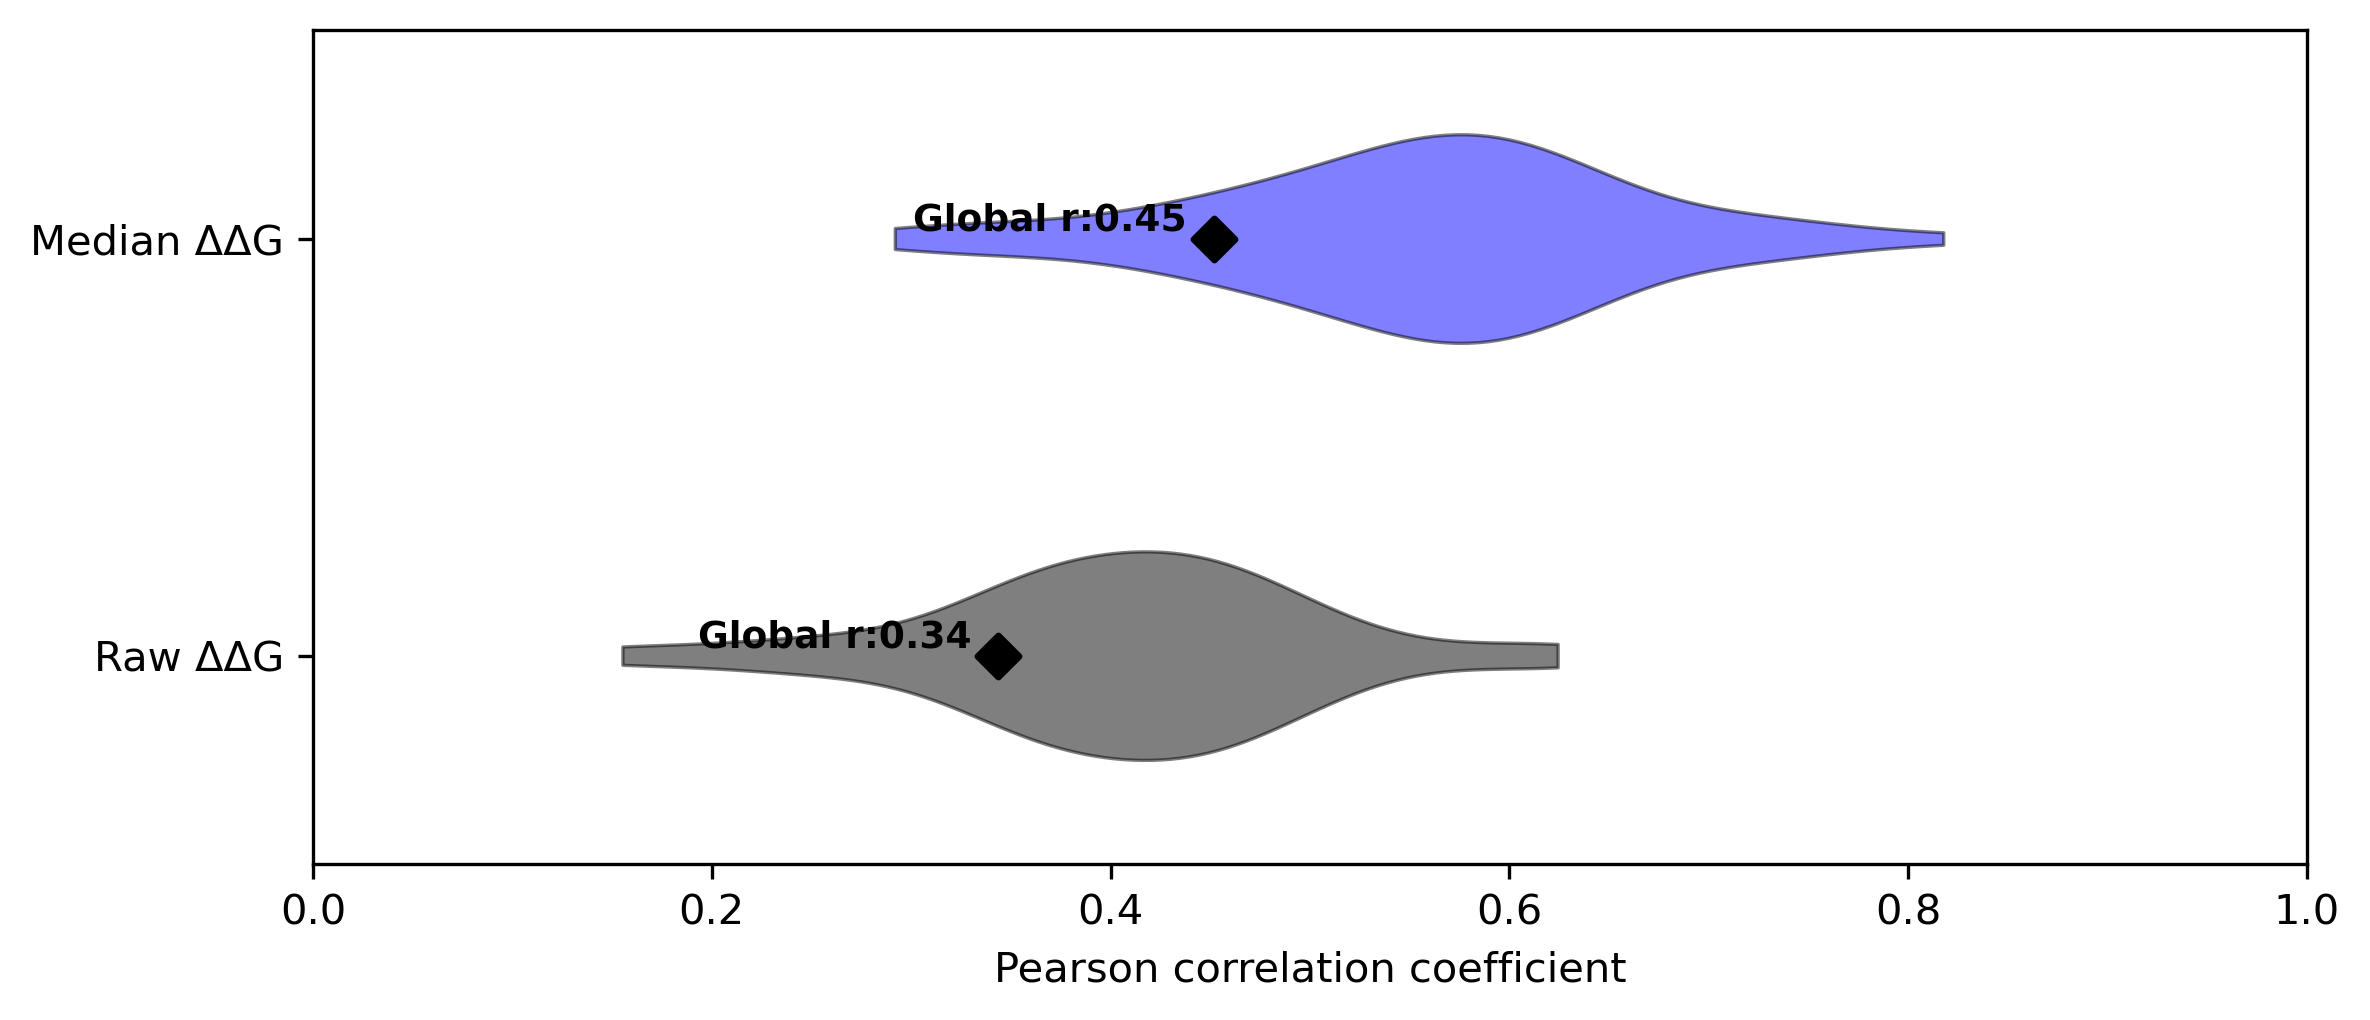

In [36]:
fig, ax = plt.subplots(figsize=(8, 3.5), dpi=300)

# Violin plot 
data = [raw_r, median_r]          
y_positions = [0, 1]              

parts = ax.violinplot(
    data,
    positions=y_positions,
    vert=False,                   
    showmeans=False,               
    showmedians=False,             
    showextrema=False,
    widths=0.5
)

# Style the violins
colors = ['k', 'b']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.5)
    pc.set_edgecolor('black')
    pc.set_linewidth(0.8)

# Style mean lines
if 'cmeans' in parts:
    parts['cmeans'].set_color('black')   
    parts['cmeans'].set_linewidth(2)
    parts['cmeans'].set_linestyle('-')

# Style median lines
if 'cmedians' in parts:
    parts['cmedians'].set_color('black')  
    parts['cmedians'].set_linewidth(2)
    parts['cmedians'].set_linestyle('--')

#  Global correlations 
ax.scatter(r_global, 0, s=50, marker="D", edgecolor="k", facecolor="k",
           linewidth=1.5, zorder=5, label="Global Raw")
ax.scatter(r_global_med, 1, s=50, marker="D", edgecolor="k", facecolor="k",
           linewidth=1.5, zorder=5, label="Global Median")

# Add labels
ax.annotate(f"Global r:{r_global:.2f}    ",
            xy=(r_global, 0),
            xytext=(6, 0),
            textcoords="offset points",
            va="bottom",
            ha="right",
            fontsize=9,
            weight="bold")

ax.annotate(f"Global r:{r_global_med:.2f}    ",
            xy=(r_global_med, 1),
            xytext=(6, 0),
            textcoords="offset points",
            va="bottom",
            ha="right",
            fontsize=9,
            weight="bold")


#  Axes formatting 
ax.set_yticks(y_positions)
ax.set_yticklabels(["Raw ΔΔG", "Median ΔΔG"])
ax.set_xlabel("Pearson correlation coefficient")
ax.set_xlim(0, 1)
ax.set_ylim(-0.5, 1.5)
#ax.legend(frameon=False)

plt.tight_layout()
plt.show()


### Dataset table of Uniprot IDs and PDB IDs used in correlation analysis

In [42]:
def get_used_pdb_codes(uid):
    if uid not in variant_data:
        return []
    codes = set()
    for rocklin_pdb_id, df_list in variant_data[uid].items():
        for df in df_list:
            if "pdb_id_pipeline" in df.columns:
                codes.update(df["pdb_id_pipeline"].unique())
    return sorted(codes)



uniprot_ids = {
    "PIN1": "Q13526",
    "spg": "P06654",
    "FYN": "P06241",
    "rplI": "P02417",
    "THO1": "P40040",
    "CPA2": "P48052",
    "PRPF40A": "O75400",
    #"sucB": "P0AFG6",
    #"VIL1": "P02640",
    #"YAP1": "P46937",    
}

high_agreement_uids = set(uniprot_ids.values())
extended_core_uids = set(correlation_all_filt["uniprot_id"].unique())  # the 25-protein core
reported_uids = high_agreement_uids | extended_core_uids


dataset_rows = []
for uid in sorted(reported_uids):
    pdb_codes = get_used_pdb_codes(uid)
    if not pdb_codes:
        print(f"WARNING: {uid} is flagged as used in an analysis but has no aligned PDB codes in variant_data -- check this one")
    dataset_rows.append({
        "uniprot_id": uid,
        "used_in_high_agreement_dataset": uid in high_agreement_uids,
        "used_in_extended_dataset": uid in extended_core_uids,
        "pdb_codes": "; ".join(pdb_codes),
    })

dataset_table = pd.DataFrame(dataset_rows).sort_values("uniprot_id")
dataset_table.to_csv("../Figures/Supp_Table_datasets_used.csv", index=False)
dataset_table

,uniprot_id,used_in_high_agreement_dataset,used_in_extended_dataset,pdb_codes
0,O14776,False,True,2MW9; 2MWA; 2MWB; 2MWD; 2MWE; 2MWF; 2N4R; 2N4S; 2N4T; 2N4U; 2N4V; 2N4W; 2NNT
1,O75400,True,False,1UZC; 2KZG; 2L9V; 2LKS
2,O95931,False,True,2K1B; 2L12; 2L1B; 4MN3; 5EPJ; 6V2R; 8SII
3,P00523,False,True,1NLO; 1NLP; 1PRL; 1PRM; 1RLP; 1RLQ; 1SRL; 1SRM; 2PTK; 3FJ5; 4HVU; 4HVV; 4HVW; 4JZ3; 4JZ4; 4LE9; 4OML; 4OMM; 4OMN; 4OMO; 4OMP; 4OMQ; 4QT7; 4RTU; 4RTV; 4RTW; 4RTX; 4RTY; 4RTZ; 5EC7; 5ECA; 5I11; 5OAV; 5OB0; 5OB1; 5OB2; 6XVM; 6XVN; 6XVO; 6XX2; 6XX3; 6XX4; 6XX5; 7A30; 7A31; 7A32; 7A33; 7A34; 7A35; 7A36; 7A37; 7A38; 7A39; 7A3A; 7A3B; 7A3C; 7A3D; 7A3E; 7NER; 7NET; 7PVW; 7PVX; 7PVY; 7PVZ; 7PW0
4,P02417,True,False,1CQU; 1DIV; 2HBA; 2HBB; 2HVF
5,P02640,False,True,1QQV; 1VII; 1WY3; 1WY4; 1YRF; 1YRI; 1YU5; 1YU7; 1YU8; 2F4K; 2JM0; 2PPZ; 2RJV; 2RJW; 2RJX; 2RJY; 3MYA; 3MYC; 3MYE; 3NKJ; 3TJW; 3TRV; 3TRW; 4CZ3; 4CZ4; 5I1N; 5I1O; 5I1P; 5I1S; 9MF7; 9MF8; 9MF9; 9MFA
6,P02836,False,True,1DU0; 1ENH; 1HDD; 1P7I; 1P7J; 1ZTR; 2HDD; 2HOS; 2HOT; 2JWT; 2P81; 3HDD; 6FVC; 6M3D
7,P03040,False,True,1COP; 1D1L; 1D1M; 1ORC; 2A63; 2ORC; 2OVG; 3ORC; 5CRO; 6CRO
8,P06239,False,True,1H92; 1KIK; 1LCK; 1X27; 2IIM; 4D8K; 5MTM; 8X2P
9,P06241,True,True,1A0N; 1AZG; 1FYN; 1G83; 1NYF; 1NYG; 1SHF; 1ZBJ; 3H0F; 3H0H; 3H0I; 3UA6; 3UA7; 4EIK; 4ZNX; 6EDF; 6IPY; 6IPZ; 7A2J; 7A2K; 7A2L; 7A2M; 7A2N; 7A2O; 7A2P; 7A2Q; 7A2R; 7A2S; 7A2T; 7A2U; 7A2V; 7A2W; 7A2X; 7A2Y; 7A2Z; 7UD6; 8KDX


## Structural subclass / fold-family analysis



ALL proteins in Rocklin paper grouped by superfamily. For each Uniprot ID the csv lists every candidate superfamily listed in Interpro, together with which of that proteins PDB structures (if any) overlap the candidate's residue range.  


In [80]:
pdb_superfamily_df = pd.read_csv("pdb_ids_by_superfamily.csv")
pdb_superfamily_df.head()

,uniprot_id,interpro_superfamily_id,interpro_superfamily_name,superfamily_uniprot_residues,n_pdb_ids_total_for_uniprot,n_pdb_ids_overlapping,pdb_ids_overlapping,notes
0,A0A066R7V5,IPR036259,MFS transporter superfamily,NaN,1,1.0,2ru9,only one homologous_superfamily entry exists for this protein; all pdb_ids attributed to it without residue-range overlap checking.
1,A0A0H2URM0,NaN,NaN,NaN,1,NaN,2m7o,no homologous_superfamily-type entry found for this protein; pdb_ids listed without any overlap filtering.
2,A0A0H2YV13,IPR036028,SH3-like domain superfamily,NaN,1,1.0,2kyb,only one homologous_superfamily entry exists for this protein; all pdb_ids attributed to it without residue-range overlap checking.
3,A0A0H3AYC3,IPR012340,"Nucleic acid-binding, OB-fold",NaN,1,1.0,2lss,only one homologous_superfamily entry exists for this protein; all pdb_ids attributed to it without residue-range overlap checking.
4,A0A0J9X1W7,IPR009063,Immunoglobulin/albumin-binding domain superfamily,NaN,1,1.0,2mh8,only one homologous_superfamily entry exists for this protein; all pdb_ids attributed to it without residue-range overlap checking.


In [81]:
# IPR011011 (Zinc finger, FYVE/PHD-type) / IPR013083 (Zinc finger, RING/FYVE/PHD-type) is
# included despite n=1 evidence, on the same "combined vs. specific" naming logic as CBM2/3
# vs. CBM3 below: IPR013083 is the broader entry (RING+FYVE+PHD, all cross-brace zinc fingers
# sharing one fold), IPR011011 is the narrower one (just FYVE+PHD) -- and containment was 0.98,
# nearly as strong as CBM's 1.00.
SUPERFAMILY_CANONICAL_MAP = {}  # member_id -> (canonical_id, canonical_name)
_canonical_clusters = [
    # (canonical_id, canonical_name, [all member ids incl. canonical])
    ("IPR012675", "Beta-grasp domain superfamily", ["IPR012675", "IPR016155"]),
    ("IPR036390", "Winged helix DNA-binding domain superfamily", ["IPR036388", "IPR036390"]),
    ("IPR043502", "DNA/RNA polymerase superfamily", ["IPR043128", "IPR043502"]),
    ("IPR036179", "Immunoglobulin-like domain superfamily", ["IPR013783", "IPR036116", "IPR036179"]),
    ("IPR025543", "Dodecin-like", ["IPR025543", "IPR036275"]),
    ("IPR027417", "P-loop containing nucleoside triphosphate hydrolase", ["IPR027417", "IPR036961"]),
    ("IPR008965", "CBM2/CBM3, carbohydrate-binding domain superfamily", ["IPR008965", "IPR036966"]),
    ("IPR036935", "Large ribosomal subunit protein bL9, N-terminal domain superfamily", ["IPR009027", "IPR036935"]),
    ("IPR013083", "Zinc finger, RING/FYVE/PHD-type", ["IPR011011", "IPR013083"]),
]
for canon_id, canon_name, members in _canonical_clusters:
    for m in members:
        SUPERFAMILY_CANONICAL_MAP[m] = (canon_id, canon_name)

_before_ids = pdb_superfamily_df["interpro_superfamily_id"].copy()
_mapped = pdb_superfamily_df["interpro_superfamily_id"].map(
    lambda x: SUPERFAMILY_CANONICAL_MAP.get(x, (x, None))[0] if pd.notna(x) else x
)
_mapped_name = pdb_superfamily_df["interpro_superfamily_id"].map(
    lambda x: SUPERFAMILY_CANONICAL_MAP.get(x, (None, None))[1] if pd.notna(x) else x
)
_n_remapped = (_mapped != _before_ids).sum()
pdb_superfamily_df["interpro_superfamily_id"] = _mapped
pdb_superfamily_df.loc[_mapped_name.notna(), "interpro_superfamily_name"] = _mapped_name[_mapped_name.notna()]
print(f"Canonicalized {_n_remapped} rows across {len(_canonical_clusters)} merged superfamily clusters.")

# Consolidate: a protein can now have two rows that map to the SAME canonical id so merge those into one row 
def _union_pdb_ids(series):
    ids = set()
    for val in series.dropna():
        ids.update(x.strip() for x in str(val).split(";") if x.strip())
    return ";".join(sorted(ids)) if ids else np.nan

pdb_superfamily_df = (
    pdb_superfamily_df
    .groupby(["uniprot_id", "interpro_superfamily_id"], dropna=False, as_index=False)
    .agg({
        "interpro_superfamily_name": "first",
        "superfamily_uniprot_residues": "first",
        "n_pdb_ids_total_for_uniprot": "first",
        "pdb_ids_overlapping": _union_pdb_ids,
        "notes": "first",
    })
)
pdb_superfamily_df["n_pdb_ids_overlapping"] = pdb_superfamily_df["pdb_ids_overlapping"].apply(
    lambda x: len(str(x).split(";")) if pd.notna(x) else np.nan
)

Canonicalized 33 rows across 9 merged superfamily clusters.


In [82]:
family_rows = []
for uniprot_id, grp in pdb_superfamily_df.groupby("uniprot_id"):
    resolved = grp.dropna(subset=["interpro_superfamily_id", "pdb_ids_overlapping"])
    if len(resolved) == 1:
        sf_id = resolved["interpro_superfamily_id"].iloc[0]
        sf_name = resolved["interpro_superfamily_name"].iloc[0]
        status = "single_resolved_superfamily"
    elif len(resolved) > 1:
        sf_id, sf_name = np.nan, np.nan
        status = f"splits_across_{len(resolved)}_superfamilies_by_structure"
    else:
        sf_id, sf_name = np.nan, np.nan
        status = "no_superfamily_resolved"
    family_rows.append({
        "uniprot_id": uniprot_id,
        "interpro_superfamily_id": sf_id,
        "interpro_superfamily_name": sf_name,
        "n_candidate_superfamilies": grp["interpro_superfamily_id"].notna().sum(),
        "status": status,
    })

family_df = pd.DataFrame(family_rows).set_index("uniprot_id")


family_df[["interpro_superfamily_id", "interpro_superfamily_name", "n_candidate_superfamilies", "status"]]


,interpro_superfamily_id,interpro_superfamily_name,n_candidate_superfamilies,status
uniprot_id,,,,
A0A066R7V5,IPR036259,MFS transporter superfamily,1,single_resolved_superfamily
A0A0H2URM0,NaN,NaN,0,no_superfamily_resolved
A0A0H2YV13,IPR036028,SH3-like domain superfamily,1,single_resolved_superfamily
A0A0H3AYC3,IPR012340,"Nucleic acid-binding, OB-fold",1,single_resolved_superfamily
A0A0J9X1W7,IPR009063,Immunoglobulin/albumin-binding domain superfamily,1,single_resolved_superfamily
A0A173DW12,IPR044894,"TubC, N-terminal docking domain superfamily",5,single_resolved_superfamily
A0A173DW33,IPR044894,"TubC, N-terminal docking domain superfamily",4,single_resolved_superfamily
A0A173DW42,IPR044894,"TubC, N-terminal docking domain superfamily",2,single_resolved_superfamily
A0A480YEE4,IPR036028,SH3-like domain superfamily,1,single_resolved_superfamily


In [83]:
# Build (uniprot_id, pdb_id) --> superfamily lookup

structure_superfamily_lookup = {}
_conflicts = []
for _, row in pdb_superfamily_df.dropna(subset=["interpro_superfamily_id", "pdb_ids_overlapping"]).iterrows():
    for pdb_id in str(row["pdb_ids_overlapping"]).split(";"):
        key = (row["uniprot_id"], pdb_id.strip().upper())
        if key in structure_superfamily_lookup and structure_superfamily_lookup[key][0] != row["interpro_superfamily_id"]:
            _conflicts.append((key, structure_superfamily_lookup[key][0], row["interpro_superfamily_id"]))
        structure_superfamily_lookup[key] = (row["interpro_superfamily_id"], row["interpro_superfamily_name"])

# A structure matched by residue-range overlap to more than one candidate superfamily is not
# actually resolved -- drop it back to unresolved (falls through to the protein-level value).
if _conflicts:
    print(f"{len(_conflicts)} (uniprot_id, pdb_id) pairs overlapped more than one candidate "
          f"superfamily -- left unresolved at the structure level:")

print(f"{len(structure_superfamily_lookup)} individual (uniprot_id, pdb_id) structures resolved to "
      f"a specific InterPro superfamily via residue-range matching.")


def structure_level_superfamily(uniprot_id, pdb_id):
    """Per-structure superfamily; falls back to the protein-level family_df value (itself NaN
    for proteins that are still genuinely ambiguous or have no superfamily-type entry at all)."""
    key = (uniprot_id, str(pdb_id).strip().upper())
    if key in structure_superfamily_lookup:
        return structure_superfamily_lookup[key]
    if uniprot_id in family_df.index:
        return family_df.loc[uniprot_id, "interpro_superfamily_id"], family_df.loc[uniprot_id, "interpro_superfamily_name"]
    return np.nan, np.nan


883 (uniprot_id, pdb_id) pairs overlapped more than one candidate superfamily -- left unresolved at the structure level:
2059 individual (uniprot_id, pdb_id) structures resolved to a specific InterPro superfamily via residue-range matching.


In [84]:
# Filter eligilble proteins to min no of varaints =5 (basic floor for meaningful correlation)


MIN_VARIANTS_ALL = 5  


_rocklin_mean_all = {}
for uniprot_id, df in Rocklin2_data_unfiltered.items():
    if df is None or df.empty:
        continue
    _rocklin_mean_all[uniprot_id] = {}
    grouped = df.groupby(["uniprot_id", "pdb_id", "variant_rebased"], as_index=False)["ddg_rebased"].mean()
    grouped = grouped.rename(columns={"ddg_rebased": "ddg_rebased_rocklin"})
    for pdb_id, subdf in grouped.groupby("pdb_id"):
        _rocklin_mean_all[uniprot_id][pdb_id] = subdf.reset_index(drop=True)

_variant_data_all = defaultdict(lambda: defaultdict(list))
for uniprot_id, pipeline_pdb_dict in pipeline_data_meanhomo.items():
    rocklin_pdb_dict = _rocklin_mean_all.get(uniprot_id)
    if not rocklin_pdb_dict:
        continue
    for rocklin_pdb_id, rocklin_df in rocklin_pdb_dict.items():
        for pipeline_pdb_id, pipeline_df in pipeline_pdb_dict.items():
            merged_df = pipeline_df.merge(rocklin_df, on=["uniprot_id", "variant_rebased"],
                                           how="inner", suffixes=("_pipeline", "_rocklin"))
            if not merged_df.empty:
                _variant_data_all[uniprot_id][rocklin_pdb_id].append(merged_df)

variant_median_data_all = defaultdict(dict)
for uniprot_id, rocklin_dict in _variant_data_all.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():
        if not df_list:
            continue
        all_df = pd.concat(df_list, ignore_index=True)
        median_df = (
            all_df.groupby("variant_rebased", as_index=False)
                  .agg(ddg_rebased_median=("ddg_rebased", "median"),
                       n_pipeline=("ddg_rebased", "count"),
                       ddg_rebased_rocklin=("ddg_rebased_rocklin", "mean"))
        )
        median_df["uniprot_id"] = uniprot_id
        median_df["rocklin_pdb_id"] = rocklin_pdb_id
        variant_median_data_all[uniprot_id][rocklin_pdb_id] = median_df[
            ["uniprot_id", "rocklin_pdb_id", "variant_rebased", "ddg_rebased_median",
             "ddg_rebased_rocklin", "n_pipeline"]
        ]






In [85]:
# Per-structure feature table. With FoldX-experiemnt agreement. 

def summarize_structure(df):
    """df: one _family_source[uniprot_id][rocklin_pdb_id] dataframe
    (columns: variant_rebased, ddg_rebased_median [FoldX], ddg_rebased_rocklin [experiment], n_pipeline)
    """
    x = df["ddg_rebased_median"].values          # FoldX, median-aggregated across pipeline structures
    y = -df["ddg_rebased_rocklin"].values         # experiment, sign-matched to FoldX convention

    out = {}

    if len(df) >= 5 and np.std(x) > 0 and np.std(y) > 0:
        r, _ = pearsonr(x, y)
        rho, _ = spearmanr(x, y)
        slope, intercept, _, _, _ = linregress(x, y)
        resid = y - (slope * x + intercept)
    else:
        r = rho = slope = intercept = outlier_frac = np.nan

    out["pearson_r"] = r
    out["spearman_r"] = rho
    out["slope"] = slope
    out["intercept"] = intercept
    return out


structure_rows = []
for uniprot_id, rocklin_dict in _family_source.items():
    for rocklin_pdb_id, df in rocklin_dict.items():
        if df.shape[0] < MIN_VARIANTS_ALL:
            continue
        row = {"uniprot_id": uniprot_id, "rocklin_pdb_id": rocklin_pdb_id}
        row.update(summarize_structure(df))
        structure_rows.append(row)

structure_features = pd.DataFrame(structure_rows)

# n_structures_median is attached as a diagnostic column only -- not used to filter here.
# correlation_all is the unfiltered join, built before the >5-structure cutoff was applied.
structure_features = structure_features.merge(
    correlation_all[["uniprot_id", "rocklin_pdb_id", "n_structures_median"]],
    on=["uniprot_id", "rocklin_pdb_id"], how="left",
)

# InterPro superfamily is resolved per STRUCTURE, not per protein. Two structures of the same multi-domain protein can land in
# different superfamily groups here.
_sf = structure_features.apply(
    lambda r: structure_level_superfamily(r["uniprot_id"], r["rocklin_pdb_id"]), axis=1, result_type="expand"
)
structure_features["interpro_superfamily_id"] = _sf[0]
structure_features["interpro_superfamily_name"] = _sf[1]

_n_structure_resolved = sum(
    (r.uniprot_id, str(r.rocklin_pdb_id).strip().upper()) in structure_superfamily_lookup
    for r in structure_features.itertuples()
)
print(f"{_n_structure_resolved}/{len(structure_features)} structures matched directly by "
      f"(uniprot_id, pdb_id) at the structure-level, the rest fell back to the "
      f"protein-level value")

missing = structure_features.loc[structure_features["interpro_superfamily_name"].isna(), "uniprot_id"].unique()
if len(missing):
    print("No superfamily resolved (protein- or structure-level) for:", list(missing))

print(f"{len(structure_features)} structures, "
      f"{structure_features['uniprot_id'].nunique()} proteins, "
      f"{structure_features['interpro_superfamily_name'].nunique()} InterPro superfamilies")
structure_features.head()

182/201 structures matched directly by (uniprot_id, pdb_id) at the structure-level, the rest fell back to the protein-level value
No superfamily resolved (protein- or structure-level) for: ['O31818', 'P74795', 'Q8TE49', 'G1K3N3', 'A0A0H2URM0', 'Q8LTJ5', 'Q80J95', 'H6WEV7', 'Q9QEJ5', 'P38428', 'Q53291', 'G1K3S4', 'Q8RY59', 'I6V394', 'D3WAF4', 'A9J6U1']
201 structures, 155 proteins, 61 InterPro superfamilies


,uniprot_id,rocklin_pdb_id,pearson_r,spearman_r,slope,intercept,n_structures_median,interpro_superfamily_id,interpro_superfamily_name
0,P06241,1A0N,0.558532,0.740060,0.194342,3.072227,37.0,IPR036860,SH2 domain superfamily
1,P05766,1A32,0.624898,0.627959,0.217837,0.057306,1.0,IPR009068,"uS15/NS1, RNA-binding domain superfamily"
2,P0A6D0,1AOY,0.559792,0.678114,0.233938,0.488090,1.0,IPR036390,Winged helix DNA-binding domain superfamily
3,P07751,1BK2,0.566551,0.677480,0.259507,0.538656,46.0,IPR036028,SH3-like domain superfamily
4,P07751,1E6H,0.571511,0.688578,0.320267,-0.251283,46.0,IPR036028,SH3-like domain superfamily


In [75]:
# does agreement with experiment (r, slope) differ systematically by InterPro superfamily?
# NB only exploratory at this stage given severage groups have only 1-2 proteins

def run_family_stats(df, group_col, min_group_n=2):
    summary = (
        df.groupby(group_col)
          .agg(n_proteins=("uniprot_id", "nunique"),
               n_structures=("rocklin_pdb_id", "nunique"),
               mean_pearson_r=("pearson_r", "mean"),
               median_pearson_r=("pearson_r", "median"),
               mean_slope=("slope", "mean"),
               median_slope=("slope", "median"))
          .sort_values("mean_pearson_r", ascending=False)
    )

    def kw_test(col):
        groups = [g[col].dropna().values for _, g in df.groupby(group_col)
                  if g[col].notna().sum() >= min_group_n]
        return kruskal(*groups) if len(groups) >= 2 else None

    return summary, kw_test("pearson_r"), kw_test("slope")


fold_summary, kw_r_fold, kw_slope_fold = run_family_stats(structure_features, "interpro_superfamily_name")
print("=== By InterPro superfamily ===")
display(fold_summary)
print("Kruskal-Wallis, pearson_r across superfamilies:", kw_r_fold)
print("Kruskal-Wallis, slope across superfamilies:", kw_slope_fold)


=== By InterPro superfamily ===


,n_proteins,n_structures,mean_pearson_r,median_pearson_r,mean_slope,median_slope
interpro_superfamily_name,,,,,,
"RNA polymerase, phosphoprotein P, C-terminal XD, paramyxovirinae",2,2,0.729048,0.729048,0.368462,0.368462
Regulatory protein cro superfamily,1,1,0.726362,0.726362,0.514358,0.514358
PABC (PABP) domain,1,1,0.715154,0.715154,0.312383,0.312383
Rho GTPase activation protein,1,1,0.683153,0.683153,0.334684,0.334684
Sterile alpha motif/pointed domain superfamily,2,2,0.643619,0.643619,0.272966,0.272966
Homeodomain-like superfamily,6,9,0.627749,0.646889,0.327811,0.368592
E3-binding domain superfamily,2,5,0.625271,0.605639,0.348684,0.302142
"uS15/NS1, RNA-binding domain superfamily",1,1,0.624898,0.624898,0.217837,0.217837
"Large ribosomal subunit protein uL2, domain 2",1,1,0.607688,0.607688,0.339598,0.339598


Kruskal-Wallis, pearson_r across superfamilies: KruskalResult(statistic=np.float64(48.759570952428135), pvalue=np.float64(0.0013362376302041622))
Kruskal-Wallis, slope across superfamilies: KruskalResult(statistic=np.float64(42.108758267686824), pvalue=np.float64(0.00881716775260241))


In [78]:
# Kruskal-Wallis restricted to superfamilies with enough member proteins to support a
# within-family comparison. Of the 54 superfamily groups, most are singletons or pairs which tests indi protein noise dressed up as family structure

for min_proteins in (3, 4):
    qualifying = fold_summary[fold_summary["n_proteins"] >= min_proteins].index
    restricted = structure_features[
        structure_features["interpro_superfamily_name"].isin(qualifying)
    ]
    fold_summary_r, kw_r_r, kw_slope_r = run_family_stats(
        restricted, "interpro_superfamily_name", min_group_n=2
    )
    print(f"=== Superfamilies with >={min_proteins} proteins: {len(qualifying)} of {len(fold_summary)} groups qualify ===")
    print("Kruskal-Wallis, pearson_r:", kw_r_r)
    print("Kruskal-Wallis, slope:    ", kw_slope_r)


=== Superfamilies with >=3 proteins: 13 of 61 groups qualify ===
Kruskal-Wallis, pearson_r: KruskalResult(statistic=np.float64(23.92973321031792), pvalue=np.float64(0.02079326644191784))
Kruskal-Wallis, slope:     KruskalResult(statistic=np.float64(24.58362866643597), pvalue=np.float64(0.01692394541518069))
=== Superfamilies with >=4 proteins: 11 of 61 groups qualify ===
Kruskal-Wallis, pearson_r: KruskalResult(statistic=np.float64(20.18513606820187), pvalue=np.float64(0.027549447829843365))
Kruskal-Wallis, slope:     KruskalResult(statistic=np.float64(21.958089273112193), pvalue=np.float64(0.015319538683549535))


In [79]:
supp_table = (
    fold_summary[fold_summary["n_proteins"] >= 3]
    [["n_proteins", "n_structures", "mean_pearson_r", "mean_slope"]]
    .round(2)
    .sort_values("mean_pearson_r", ascending=False)
    .rename(columns={
        "n_proteins": "Proteins",
        "n_structures": "Structures",
        "mean_pearson_r": "Mean Pearson r",
        "mean_slope": "Mean slope",
    })
)
supp_table.index.name = "Superfamily"
display(supp_table)
supp_table.to_csv("../Figures/Supp_Table_superfamily_agreement.csv")

,Proteins,Structures,Mean Pearson r,Mean slope
Superfamily,,,,
Homeodomain-like superfamily,6,9,0.63,0.33
"TubC, N-terminal docking domain superfamily",3,3,0.59,0.30
Chaperone J-domain superfamily,4,5,0.55,0.30
Winged helix DNA-binding domain superfamily,4,4,0.55,0.22
SH2 domain superfamily,9,12,0.52,0.22
SH3-like domain superfamily,15,26,0.51,0.24
"Zinc finger, RING/FYVE/PHD-type",3,4,0.50,0.21
EF-hand domain pair,4,4,0.47,0.18
Immunoglobulin/albumin-binding domain superfamily,6,13,0.46,0.18


In [86]:
qualifying_3 = fold_summary[fold_summary["n_proteins"] >= 3].index
restricted = structure_features[structure_features["interpro_superfamily_name"].isin(qualifying_3)]

per_superfamily = restricted.groupby("interpro_superfamily_name").agg(
    n_proteins=("uniprot_id", "nunique"),
    mean_structures_per_protein=("n_structures_median", "mean"),
    mean_pearson_r=("pearson_r", "mean"),
    mean_slope=("slope", "mean"),
).sort_values("mean_pearson_r", ascending=False)

print(per_superfamily.round(3))

rho_r, p_r = spearmanr(per_superfamily["mean_structures_per_protein"], per_superfamily["mean_pearson_r"])
rho_slope, p_slope = spearmanr(per_superfamily["mean_structures_per_protein"], per_superfamily["mean_slope"])

print(f"\nmean structures/protein vs mean Pearson r: rho={rho_r:.3f}, p={p_r:.3f}")
print(f"mean structures/protein vs mean slope:     rho={rho_slope:.3f}, p={p_slope:.3f}")

                                                                                n_proteins  \
interpro_superfamily_name                                                                    
Homeodomain-like superfamily                                                             6   
TubC, N-terminal docking domain superfamily                                              3   
Chaperone J-domain superfamily                                                           4   
Winged helix DNA-binding domain superfamily                                              4   
SH2 domain superfamily                                                                   9   
SH3-like domain superfamily                                                             15   
Zinc finger, RING/FYVE/PHD-type                                                          3   
EF-hand domain pair                                                                      4   
Immunoglobulin/albumin-binding domain superfamily           

## Data export for the ENM/ProDy notebook
Representative structures selected to maximise (non-overlapping) coverage of the protein. 
Restricted to the 25-protein dataset used in correlation analysis above. 



In [90]:
# Greedy disjoint-set selection: repeatedly pick the LARGEST remaining candidate structure that
# shares ZERO residues with any structure already chosen for that protein, until no disjoint
# candidate remains. it naturally stops once every remaining candidate would overlap something already
# selected. Coverage is reported against the union of ALL candidate structures for that protein
# (the maximum achievable given the data on hand), not canonical UniProt sequence length.

candidate_residue_sets = {}   # uniprot_id -> {pdb_id: set(res)}

proteins_25 = set(correlation_all_filt["uniprot_id"].unique())

for uid, df in pipeline_data.items():
    if uid not in proteins_25:
        continue
    if df is None or df.empty:
        continue
    candidate_residue_sets[uid] = {
        pdb_id: set(sub["res"].unique())
        for pdb_id, sub in df.groupby("pdb_id")
    }


def greedy_disjoint_max_coverage(residue_sets):
    total_achievable = set()
    for s in residue_sets.values():
        total_achievable |= s

    remaining = dict(residue_sets)
    covered = set()
    chosen = []
    while remaining:
        disjoint_candidates = {pdb: res for pdb, res in remaining.items() if not (res & covered)}
        if not disjoint_candidates:
            break
        best_pdb = max(disjoint_candidates, key=lambda p: len(disjoint_candidates[p]))
        best_res = disjoint_candidates[best_pdb]
        covered |= best_res
        chosen.append({
            "pdb_id": best_pdb,
            "n_residues_this_structure": len(best_res),
            "cumulative_n_residues": len(covered),
        })
        del remaining[best_pdb]
    return chosen, total_achievable


representative_rows = []
for uid, residue_sets in candidate_residue_sets.items():
    chosen, total_achievable = greedy_disjoint_max_coverage(residue_sets)
    n_achievable = len(total_achievable)
    for rank, entry in enumerate(chosen, start=1):
        representative_rows.append({
            "uniprot_id": uid,
            "rank": rank,
            "pdb_id": entry["pdb_id"],
            "n_residues_this_structure": entry["n_residues_this_structure"],
            "cumulative_n_residues": entry["cumulative_n_residues"],
            "n_achievable_residues": n_achievable,   # union of ALL candidate structures, not canonical length
            "cumulative_coverage_frac": (entry["cumulative_n_residues"] / n_achievable
                                          if n_achievable else np.nan),
        })

representative_pdb_df = pd.DataFrame(representative_rows)
representative_pdb_df.to_csv("../Output/representative_structures.csv", index=False)

n_multi = (representative_pdb_df.groupby("uniprot_id")["rank"].max() > 1).sum()
print(f"Selected {len(representative_pdb_df)} representative structures for "
      f"{representative_pdb_df['uniprot_id'].nunique()} proteins "
      f"({n_multi} proteins needed >1 disjoint structure to cover what's available)")
final_coverage = representative_pdb_df.sort_values("rank").groupby("uniprot_id").tail(1)
print(f"Coverage of achievable residues (all selected structures combined): "
      f"median={final_coverage['cumulative_coverage_frac'].median():.1%}, "
      f"min={final_coverage['cumulative_coverage_frac'].min():.1%}")

representative_pdb_df.head(10)


Selected 49 representative structures for 26 proteins (12 proteins needed >1 disjoint structure to cover what's available)
Coverage of achievable residues (all selected structures combined): median=100.0%, min=88.8%


,uniprot_id,rank,pdb_id,n_residues_this_structure,cumulative_n_residues,n_achievable_residues,cumulative_coverage_frac
0,P06241,1,2DQ7,262,262,431,0.607889
1,P06241,2,1G83,161,423,431,0.981439
2,P07751,1,1U4Q,318,318,382,0.832461
3,P07751,2,1E6H,61,379,382,0.992147
4,P32081,1,1CSP,67,67,67,1.000000
5,P06654,1,1PGX,68,68,124,0.548387
6,P06654,2,3MP9,56,124,124,1.000000
7,P02836,1,2JWT,60,60,60,1.000000
8,P19909,1,2IGG,64,64,220,0.290909
9,P19909,2,2N9K,55,119,220,0.540909


In [ ]:
def coverage_curve_for_structure(df_list, n_boot=30, min_variants=5, random_state=None):
    """df_list: variant_data[uniprot_id][rocklin_pdb_id], a list of per-pipeline-structure
    DataFrames (columns include variant_rebased, ddg_rebased, ddg_rebased_rocklin).
    Returns one row per k = number of structures aggregated, with the bootstrap mean/CI
    of Pearson r between median-aggregated FoldX ddG and experiment."""
    rng = np.random.default_rng(random_state)
    n_avail = len(df_list)
    rows = []
    for k in range(1, n_avail + 1):
        rs = []
        for _ in range(n_boot):
            idx = rng.choice(n_avail, size=k, replace=False)
            sub = pd.concat([df_list[i] for i in idx], ignore_index=True)
            med = sub.groupby("variant_rebased", as_index=False).agg(
                ddg_rebased_median=("ddg_rebased", "median"),
                ddg_rebased_rocklin=("ddg_rebased_rocklin", "first"),
            )
            if med.shape[0] < min_variants or med["ddg_rebased_median"].std() == 0:
                continue
            r, _ = pearsonr(med["ddg_rebased_median"], -med["ddg_rebased_rocklin"])
            rs.append(r)
        if rs:
            rows.append({"k": k, "n_available": n_avail, "r_mean": np.mean(rs),
                         "r_lo": np.percentile(rs, 2.5), "r_hi": np.percentile(rs, 97.5)})
    return pd.DataFrame(rows)


curve_rows = []
for uniprot_id, rocklin_dict in variant_data.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():
        if len(df_list) < 2:
            continue
        curve = coverage_curve_for_structure(df_list, random_state=42)
        if curve.empty:
            continue
        curve["uniprot_id"] = uniprot_id
        curve["rocklin_pdb_id"] = rocklin_pdb_id
        curve_rows.append(curve)

coverage_curve_df = pd.concat(curve_rows, ignore_index=True)
coverage_curve_df["k_fraction"] = coverage_curve_df["k"] / coverage_curve_df["n_available"]
print(f"Coverage curve computed for {coverage_curve_df[['uniprot_id', 'rocklin_pdb_id']].drop_duplicates().shape[0]} structures")


In [ ]:
# Headline single-structure vs. full-ensemble numbers for the rebuttal
headline = (
    coverage_curve_df.sort_values("k")
    .groupby(["uniprot_id", "rocklin_pdb_id"])
    .agg(r_at_k1=("r_mean", "first"), r_at_kmax=("r_mean", "last"), n_available=("n_available", "first"))
)
print(f"Mean r using a single structure (k=1):      {headline['r_at_k1'].mean():.3f}")
print(f"Mean r using the full available ensemble:   {headline['r_at_kmax'].mean():.3f}")
display(headline.sort_values("n_available", ascending=False))

# Pooled, coverage-normalised trend (fraction of each structure's own max coverage -> r),
# since absolute k isn't comparable across proteins with very different numbers of models
coverage_curve_df["k_frac_bin"] = pd.cut(coverage_curve_df["k_fraction"], bins=np.linspace(0, 1, 11))
pooled_trend = coverage_curve_df.groupby("k_frac_bin", observed=True)["r_mean"].agg(["mean", "std", "count"])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

cmap = plt.get_cmap("tab20")
for i, ((uid, pdb), g) in enumerate(coverage_curve_df.groupby(["uniprot_id", "rocklin_pdb_id"])):
    axes[0].plot(g["k"], g["r_mean"], alpha=0.5, color=cmap(i % 20), linewidth=1)
axes[0].set_xlabel("Number of structures aggregated (k)")
axes[0].set_ylabel("Pearson r vs. experiment")
axes[0].set_title("Per-structure coverage curves")

axes[1].plot(range(len(pooled_trend)), pooled_trend["mean"], marker="o", color="black")
axes[1].fill_between(range(len(pooled_trend)),
                      pooled_trend["mean"] - pooled_trend["std"],
                      pooled_trend["mean"] + pooled_trend["std"], alpha=0.2)
axes[1].set_xticks(range(len(pooled_trend)))
axes[1].set_xticklabels([str(b) for b in pooled_trend.index], rotation=45, ha="right", fontsize=7)
axes[1].set_xlabel("Fraction of that structure's available coverage")
axes[1].set_ylabel("Mean Pearson r (+/- 1 SD across structures)")
axes[1].set_title("Pooled, coverage-normalised trend")

plt.tight_layout()
plt.savefig("coverage_curve.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Derive k* empirically from the coverage curve built above (coverage_curve_df, headline).
MIN_N_AVAILABLE_FOR_ASYMPTOTE = 8   # need enough headroom to define a stable "eventual" r per structure
RECOVERY_TARGET = 0.9               # require pooled recovery >= 90% of that structure's own full-coverage r

eligible = headline[headline["n_available"] >= MIN_N_AVAILABLE_FOR_ASYMPTOTE]
print(f"{len(eligible)} of {len(headline)} structures have n_available >= {MIN_N_AVAILABLE_FOR_ASYMPTOTE}, "
      f"used to define the full-coverage asymptote")

if len(eligible) == 0:
    k_star = 5
    print("WARNING: no structures with enough coverage to derive k* reliably; falling back to the default threshold of 5")
    pooled_recovery = pd.DataFrame()
else:
    k_max_common = int(eligible["n_available"].min())  # k-range every eligible structure has data for
    merged = coverage_curve_df.merge(
        eligible[["r_at_kmax"]], left_on=["uniprot_id", "rocklin_pdb_id"], right_index=True, how="inner"
    )
    merged = merged[merged["k"] <= k_max_common].copy()
    merged["recovery"] = merged["r_mean"] / merged["r_at_kmax"]

    pooled_recovery = merged.groupby("k")["recovery"].agg(["mean", "std", "count"])

    meets = pooled_recovery["mean"] >= RECOVERY_TARGET
    k_star = None
    for k in pooled_recovery.index:
        if meets.loc[k:].all():
            k_star = int(k)
            break
    if k_star is None:
        k_star = k_max_common
        print(f"Pooled recovery never sustained >= {RECOVERY_TARGET:.0%}; falling back to k* = k_max_common = {k_max_common}")

print(f"\nDerived k* = {k_star} (on average, structures need >= {k_star} pipeline structures to reach "
      f"{RECOVERY_TARGET:.0%} of their own full-coverage accuracy)")
print(f"Currently-applied threshold in this notebook: > 5 structures "
      f"({'consistent with' if abs(k_star - 5) <= 1 else 'differs from'} the empirically-derived k*)")

if not pooled_recovery.empty:
    fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
    ax.errorbar(pooled_recovery.index, pooled_recovery["mean"], yerr=pooled_recovery["std"],
                marker="o", color="black", capsize=3)
    ax.axhline(RECOVERY_TARGET, color="grey", linestyle="--", linewidth=1, label=f"{RECOVERY_TARGET:.0%} recovery target")
    ax.axvline(k_star, color="tab:red", linestyle=":", linewidth=1.5, label=f"k* = {k_star}")
    ax.set_xlabel("Number of pipeline structures aggregated (k)")
    ax.set_ylabel("Recovery of full-coverage accuracy\n(pooled mean +/- 1 SD)")
    ax.set_title("Empirical derivation of the coverage threshold")
    ax.legend()
    plt.tight_layout()
    plt.savefig("coverage_threshold_derivation.png", dpi=300, bbox_inches="tight")
    plt.show()

pooled_recovery

In [ ]:
# Threshold sensitivity table: do the headline correlation numbers actually depend on
# where we draw the coverage-count cutoff? Recompute at several candidate thresholds,
# using the same criterion as correlation_all_filt above (n_structures_median > threshold).
#
# Reports THREE different "global r" quantities so it is clear which one is moving:
#   - global_pooled_*_r_raw:        pooled over every individual pipeline-structure reading
#     (one point per variant per contributing pipeline structure, unaggregated)
#   - global_pooled_*_r_median_ddg: pooled over one point per variant per passing Rocklin
#     structure, using that variant's MEDIAN ddG across its pipeline structures (the
#     quantity actually used for prediction/reporting elsewhere in the paper)
#   - mean_per_structure_pearson_r_median: the average of each structure's OWN separately
#     computed median-ddG correlation (weights every structure equally regardless of how
#     many variants it has, unlike the pooled version above)

def pooled_r_for_threshold(threshold, correlation_all, variant_data, variant_median_data):
    passing = correlation_all[correlation_all["n_structures_median"] > threshold]
    keys = set(zip(passing["uniprot_id"], passing["rocklin_pdb_id"]))

    # --- pooled global r, raw (unaggregated) ddG ---
    x_all, y_all = [], []
    for uniprot_id, rocklin_dict in variant_data.items():
        for rocklin_pdb_id, df_list in rocklin_dict.items():
            if (uniprot_id, rocklin_pdb_id) not in keys or not df_list:
                continue
            combined_df = pd.concat(df_list, ignore_index=True)
            if combined_df.shape[0] < 1:
                continue
            x_all.extend(combined_df["ddg_rebased"].values)
            y_all.extend(-combined_df["ddg_rebased_rocklin"].values)
    x_all, y_all = np.asarray(x_all), np.asarray(y_all)
    if len(x_all) < 2 or np.std(x_all) == 0 or np.std(y_all) == 0:
        global_pearson = global_spearman = np.nan
    else:
        global_pearson, _ = pearsonr(x_all, y_all)
        global_spearman, _ = spearmanr(x_all, y_all)

    # --- pooled global r, median-aggregated ddG (one point per variant per passing structure) ---
    x_med_all, y_med_all = [], []
    for uniprot_id, rocklin_dict in variant_median_data.items():
        for rocklin_pdb_id, df in rocklin_dict.items():
            if (uniprot_id, rocklin_pdb_id) not in keys or df is None or df.shape[0] < 1:
                continue
            x_med_all.extend(df["ddg_rebased_median"].values)
            y_med_all.extend(df["ddg_rebased_rocklin"].values)
    x_med_all = np.asarray(x_med_all)
    y_med_all = -np.asarray(y_med_all)
    if len(x_med_all) < 2 or np.std(x_med_all) == 0 or np.std(y_med_all) == 0:
        global_pearson_med = global_spearman_med = np.nan
    else:
        global_pearson_med, _ = pearsonr(x_med_all, y_med_all)
        global_spearman_med, _ = spearmanr(x_med_all, y_med_all)

    return {
        "threshold": threshold,
        "n_structures": len(passing),
        "n_proteins": passing["uniprot_id"].nunique(),
        "n_variant_obs_pooled_raw": len(x_all),
        "global_pooled_pearson_r_raw": global_pearson,
        "global_pooled_spearman_r_raw": global_spearman,
        "n_variant_obs_pooled_median": len(x_med_all),
        "global_pooled_pearson_r_median_ddg": global_pearson_med,
        "global_pooled_spearman_r_median_ddg": global_spearman_med,
        "mean_per_structure_pearson_r_median": passing["pearson_r_median"].mean(),
    }

thresholds_to_check = sorted(set([1, 3, 5, k_star, 10]))
sensitivity_rows = [pooled_r_for_threshold(t, correlation_all, variant_data, variant_median_data) for t in thresholds_to_check]
sensitivity_table = pd.DataFrame(sensitivity_rows).set_index("threshold")
sensitivity_table.to_csv("coverage_threshold_sensitivity.csv")

print("Threshold sensitivity (main results recomputed at each candidate coverage cutoff):")
sensitivity_table

### What `>5` was actually protecting against: median stability, not correlation accuracy

Same reframing as the residue threshold: the original reason for requiring more than 5 pipeline structures was that the *median* ddG for a variant isn't a reliable point estimate with too few replicate FoldX structures contributing to it -- not (only) that it improves the downstream correlation with experiment, which is what `k*` above measured.

The classic large-sample approximation for the sampling error of a **median** (via the delta method, assuming an approximately symmetric error distribution) is `SE(median) ~= 1.2533 * sigma / sqrt(k)`, where `sigma` is the per-variant standard deviation across pipeline structures and `k` is the number of structures aggregated -- about 25% noisier than the standard error of the mean at the same `k`, since the median discards some information relative to the mean. This is only an asymptotic approximation, so below we also validate it empirically: for variants with enough pipeline replicates on record to act as a reliable pool, we bootstrap-resample `k` of them, recompute the median, and measure how much that resampled median actually varies, pooled (relative to each variant's own sigma) across many variants.

In [ ]:
# Per-variant sigma: standard deviation of ddg_rebased across pipeline structures, for variants
# with enough replicates to estimate sigma reliably. Also stash each variant's full set of
# pipeline readings, needed for the bootstrap below.
MIN_PIPELINE_FOR_SIGMA = 8

per_variant_values = {}  # (uniprot_id, rocklin_pdb_id, variant_rebased) -> np.array of ddg_rebased
sigma_rows = []
for uniprot_id, rocklin_dict in variant_data.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():
        if not df_list:
            continue
        combined_df = pd.concat(df_list, ignore_index=True)
        for variant, g in combined_df.groupby("variant_rebased"):
            vals = g["ddg_rebased"].values
            if len(vals) >= MIN_PIPELINE_FOR_SIGMA:
                per_variant_values[(uniprot_id, rocklin_pdb_id, variant)] = vals
                sigma_rows.append({"uniprot_id": uniprot_id, "rocklin_pdb_id": rocklin_pdb_id,
                                    "variant": variant, "n_pipeline": len(vals),
                                    "sigma": np.std(vals, ddof=1)})

sigma_df = pd.DataFrame(sigma_rows)
print(f"{len(sigma_df)} (structure, variant) pairs with >= {MIN_PIPELINE_FOR_SIGMA} pipeline "
      f"replicates, usable to estimate sigma and validate median stability")
print(sigma_df["sigma"].describe())

In [ ]:
# Empirical bootstrap SE of the median at each k (structures aggregated), normalised by each
# variant's own sigma so results are comparable/poolable across variants of very different
# scale, compared against the theoretical 1.2533/sqrt(k) delta-method curve.
MAX_K = 15
N_BOOT = 40
MAX_VARIANTS_SAMPLED = 300  # cap for runtime; random subsample of eligible variants

rng = np.random.default_rng(0)
sample_keys = list(per_variant_values.keys())
if len(sample_keys) > MAX_VARIANTS_SAMPLED:
    idx = rng.choice(len(sample_keys), size=MAX_VARIANTS_SAMPLED, replace=False)
    sample_keys = [sample_keys[i] for i in idx]

relative_se_by_k = defaultdict(list)
for key in sample_keys:
    vals = per_variant_values[key]
    n_avail = len(vals)
    sigma = np.std(vals, ddof=1)
    if sigma == 0:
        continue
    for k in range(1, min(MAX_K, n_avail) + 1):
        boot_medians = [np.median(vals[rng.choice(n_avail, size=k, replace=False)]) for _ in range(N_BOOT)]
        se_k = np.std(boot_medians, ddof=1) if len(boot_medians) > 1 else np.nan
        relative_se_by_k[k].append(se_k / sigma)

empirical_se = pd.Series({k: np.mean(v) for k, v in relative_se_by_k.items()}).sort_index()
theoretical_se = pd.Series({k: 1.2533 / np.sqrt(k) for k in empirical_se.index})

median_stability_table = pd.DataFrame({"empirical_relative_SE": empirical_se, "theoretical_relative_SE": theoretical_se})
median_stability_table.to_csv("median_stability_vs_k.csv")

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=200)
ax.plot(theoretical_se.index, theoretical_se.values, label="theoretical: 1.2533 / sqrt(k)", color="black")
ax.plot(empirical_se.index, empirical_se.values, label="empirical (bootstrap)", color="tab:blue", marker="o")
ax.axvline(5, color="tab:red", linestyle=":", linewidth=1.5, label="current cutoff (>5 structures)")
if "k_star" in globals():
    ax.axvline(k_star, color="tab:green", linestyle="--", linewidth=1, label=f"k* (accuracy-derived, ={k_star})")
ax.set_xlabel("k (number of structures aggregated)")
ax.set_ylabel("SE(median) / sigma")
ax.set_title("Stability of the median ddG estimate vs. number of structures")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("median_stability_vs_k.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"At k=5 (current cutoff): empirical relative SE(median) = {empirical_se.get(5, float('nan')):.3f}, "
      f"theoretical = {theoretical_se.get(5, float('nan')):.3f}\n"
      f"(i.e. aggregating 5 structures cuts single-structure noise to roughly "
      f"{100*empirical_se.get(5, float('nan')):.0f}% of its original size)")
median_stability_table

In [ ]:
# Reference domain length per protein, derived from ROCKLIN2 structures (not pipeline/FoldX
# structures). Rocklin2 experimental structures are, by construction of the dataset, always
# confined to the small assayed domain -- unlike pipeline structures, which can include
# full-length or multi-domain models that inflated this denominator when we used pipeline
# data (a protein could have one huge pipeline structure among several correctly domain-sized
# ones, and taking the max over "any pipeline pdb_id" picked up the outlier every time).
#
# Uses Rocklin2_data_unfiltered (stashed before the >6-residue filter, see near the top of the
# notebook) so proteins are not penalised for having only fragmentary Rocklin structures on
# record -- we take the largest resolved-residue count seen across ALL of that protein's
# Rocklin2 structures as the best available estimate of the true domain length.
#
# Caveat: if a protein's Rocklin2 structures are *all* fragmentary (none near-complete), this
# will underestimate the true domain length and inflate pct_resolved for that protein's
# structures. This is a much smaller risk than the multi-domain contamination it replaces,
# but worth keeping in mind when reading outlier rows below.
domain_reference_length = {
    uid: df.groupby("pdb_id")["res"].nunique().max()
    for uid, df in Rocklin2_data_unfiltered.items() if df is not None and not df.empty
}
print(f"Derived a reference domain length for {len(domain_reference_length)} proteins "
      f"(from Rocklin2 structures, not pipeline structures)")
pd.Series(domain_reference_length, name="domain_reference_length").sort_values().to_frame()

In [ ]:
# Rebuild the merge/correlation pipeline on the UNFILTERED Rocklin data (mirrors cells above:
# "Take the mean of Rocklin structures..." and "Merge the datasets"), so we can see accuracy for
# structures that would have been dropped by the >6-residue filter too.

residue_counts_raw = {}  # (uniprot_id, rocklin_pdb_id) -> n unique residues resolved
Rocklin2_data_unfiltered_mean = {}
for uniprot_id, df in Rocklin2_data_unfiltered.items():
    if df is None or df.empty:
        continue
    Rocklin2_data_unfiltered_mean[uniprot_id] = {}
    grouped = df.groupby(["uniprot_id", "pdb_id", "variant_rebased"], as_index=False)["ddg_rebased"].mean()
    grouped = grouped.rename(columns={"ddg_rebased": "ddg_rebased_rocklin"})
    for pdb_id, subdf in grouped.groupby("pdb_id"):
        Rocklin2_data_unfiltered_mean[uniprot_id][pdb_id] = subdf.reset_index(drop=True)
    for pdb_id, sub in df.groupby("pdb_id"):
        residue_counts_raw[(uniprot_id, pdb_id)] = sub["res"].nunique()

variant_data_unfiltered = defaultdict(lambda: defaultdict(list))
for uniprot_id, pipeline_pdb_dict in pipeline_data_meanhomo.items():
    rocklin_pdb_dict = Rocklin2_data_unfiltered_mean.get(uniprot_id)
    if not rocklin_pdb_dict:
        continue
    for rocklin_pdb_id, rocklin_df in rocklin_pdb_dict.items():
        for pipeline_pdb_id, pipeline_df in pipeline_pdb_dict.items():
            merged_df = pipeline_df.merge(rocklin_df, on=["uniprot_id", "variant_rebased"],
                                           how="inner", suffixes=("_pipeline", "_rocklin"))
            if not merged_df.empty:
                variant_data_unfiltered[uniprot_id][rocklin_pdb_id].append(merged_df)

# Per-structure correlation + % of domain resolved, for EVERY candidate structure (no residue filter).
# Computes BOTH the raw (unaggregated) correlation and the median-aggregated one -- mirrors
# correlation_df vs. correlation_medians_df above, so we can see whether median-aggregation
# accuracy (the number actually used for prediction/reporting) responds to residue coverage
# differently than the raw per-reading correlation does.
variant_median_data_unfiltered = defaultdict(dict)
rows = []
for uniprot_id, rocklin_dict in variant_data_unfiltered.items():
    for rocklin_pdb_id, df_list in rocklin_dict.items():
        if not df_list:
            continue
        combined_df = pd.concat(df_list, ignore_index=True)
        n_res_resolved = residue_counts_raw.get((uniprot_id, rocklin_pdb_id), np.nan)
        ref_len = domain_reference_length.get(uniprot_id, np.nan)
        pct_resolved = 100 * n_res_resolved / ref_len if ref_len else np.nan
        n_variants = combined_df["variant_rebased"].nunique()

        if combined_df.shape[0] >= 2 and combined_df["ddg_rebased"].std() > 0:
            r_raw, _ = pearsonr(combined_df["ddg_rebased"], -combined_df["ddg_rebased_rocklin"])
        else:
            r_raw = np.nan

        median_df = combined_df.groupby("variant_rebased", as_index=False).agg(
            ddg_rebased_median=("ddg_rebased", "median"),
            n_pipeline=("ddg_rebased", "count"),
            ddg_rebased_rocklin=("ddg_rebased_rocklin", "mean"),
        )
        variant_median_data_unfiltered[uniprot_id][rocklin_pdb_id] = median_df
        if median_df.shape[0] >= 2 and median_df["ddg_rebased_median"].std() > 0:
            r_med, _ = pearsonr(median_df["ddg_rebased_median"], -median_df["ddg_rebased_rocklin"])
        else:
            r_med = np.nan

        rows.append({"uniprot_id": uniprot_id, "rocklin_pdb_id": rocklin_pdb_id,
                      "n_res_resolved": n_res_resolved, "domain_reference_length": ref_len,
                      "pct_resolved": pct_resolved, "n_variants": n_variants,
                      "pearson_r": r_raw, "pearson_r_median": r_med})

residue_coverage_df = pd.DataFrame(rows)
print(f"{len(residue_coverage_df)} candidate structures, unfiltered by residue count "
      f"({residue_coverage_df['uniprot_id'].nunique()} proteins)")
residue_coverage_df.sort_values("pct_resolved").head(10)

In [ ]:
# Bin by % of domain resolved and derive p* the same way k* was derived above.
MIN_VARIANTS_FOR_STABLE_R = 3   # per-structure r on fewer variants than this is too noisy to trust
RECOVERY_TARGET = 0.9

valid = residue_coverage_df[residue_coverage_df["n_variants"] >= MIN_VARIANTS_FOR_STABLE_R].copy()

bins = list(range(0, 101, 10))
valid["pct_bin"] = pd.cut(valid["pct_resolved"], bins=bins, include_lowest=True)
binned = valid.groupby("pct_bin", observed=True).agg(
    mean_r=("pearson_r", "mean"), std_r=("pearson_r", "std"),
    n_structures=("pearson_r", "count"), mean_n_variants=("n_variants", "mean"),
)
print("Binned accuracy by % of domain resolved:")
display(binned)

top_bin = valid[valid["pct_resolved"] >= 80]
asymptote_r = top_bin["pearson_r"].mean()
print(f"\nAsymptotic r (structures with >=80% resolved, n={len(top_bin)}): {asymptote_r:.3f}")

if pd.notna(asymptote_r) and len(binned) > 0:
    binned["recovery"] = binned["mean_r"] / asymptote_r
    meets = binned["recovery"] >= RECOVERY_TARGET
    bin_starts = [max(0, int(round(b.left))) for b in binned.index]
    p_star = None
    for i in range(len(binned)):
        if meets.iloc[i:].all():
            p_star = bin_starts[i]
            break
    if p_star is None:
        p_star = bin_starts[-1]
        print(f"Pooled recovery never sustained >= {RECOVERY_TARGET:.0%}; falling back to the top bin ({p_star}%)")
else:
    p_star = 10
    print("WARNING: not enough high-coverage structures to derive an asymptote reliably; "
          f"falling back to p* = {p_star}%")

print(f"\nDerived p* = {p_star}% (structures need to resolve >= {p_star}% of the domain to reach "
      f"{RECOVERY_TARGET:.0%} of the high-coverage accuracy)")

# What does the existing ">6 residues" cutoff correspond to, in relative terms, per protein?
implied_pct = 100 * 6 / pd.Series(domain_reference_length)
print(f"\n'>6 residues' corresponds to {implied_pct.median():.1f}% of the domain at the median protein "
      f"(range {implied_pct.min():.1f}%-{implied_pct.max():.1f}%) -- i.e. it is not a constant relative bar.")

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)
bin_mids = [b.mid for b in binned.index]
ax.errorbar(bin_mids, binned["mean_r"], yerr=binned["std_r"], marker="o", color="black", capsize=3)
ax.axhline(asymptote_r, color="grey", linestyle="--", linewidth=1, label="high-coverage asymptote")
ax.axvline(p_star, color="tab:red", linestyle=":", linewidth=1.5, label=f"p* = {p_star}%")
ax.set_xlabel("% of domain resolved")
ax.set_ylabel("Per-structure Pearson r vs. experiment")
ax.set_title("Empirical derivation of the residue-coverage threshold")
ax.legend()
plt.tight_layout()
plt.savefig("residue_coverage_threshold_derivation.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Residue-%-threshold sensitivity table (mirrors the structure-count sensitivity table above):
# do the headline correlation numbers actually depend on where this cutoff is drawn? Reports
# the same three "accuracy" quantities as the structure-count table:
#   - global_pooled_*_r_raw:        pooled over every individual pipeline-structure reading
#   - global_pooled_*_r_median_ddg: pooled over one point per variant per passing structure,
#     using that variant's median ddG (the quantity actually used for reporting elsewhere)
#   - mean_per_structure_pearson_r_median: average of each structure's OWN median-ddG
#     correlation (pearson_r_median from residue_coverage_df above) -- weights every
#     structure equally, so this is the number to watch for whether per-structure accuracy
#     (as opposed to the noisier pooled numbers) responds to residue coverage.

def pooled_r_for_pct_threshold(threshold_pct, variant_data_unfiltered, variant_median_data_unfiltered, residue_coverage_df):
    passing = residue_coverage_df[residue_coverage_df["pct_resolved"] > threshold_pct]
    keys = set(zip(passing["uniprot_id"], passing["rocklin_pdb_id"]))

    # --- pooled global r, raw (unaggregated) ddG ---
    x_all, y_all = [], []
    for uniprot_id, rocklin_dict in variant_data_unfiltered.items():
        for rocklin_pdb_id, df_list in rocklin_dict.items():
            if (uniprot_id, rocklin_pdb_id) not in keys or not df_list:
                continue
            combined_df = pd.concat(df_list, ignore_index=True)
            if combined_df.shape[0] < 1:
                continue
            x_all.extend(combined_df["ddg_rebased"].values)
            y_all.extend(-combined_df["ddg_rebased_rocklin"].values)
    x_all, y_all = np.asarray(x_all), np.asarray(y_all)
    if len(x_all) < 2 or np.std(x_all) == 0 or np.std(y_all) == 0:
        gp = gs = np.nan
    else:
        gp, _ = pearsonr(x_all, y_all)
        gs, _ = spearmanr(x_all, y_all)

    # --- pooled global r, median-aggregated ddG (one point per variant per passing structure) ---
    x_med_all, y_med_all = [], []
    for uniprot_id, rocklin_dict in variant_median_data_unfiltered.items():
        for rocklin_pdb_id, df in rocklin_dict.items():
            if (uniprot_id, rocklin_pdb_id) not in keys or df is None or df.shape[0] < 1:
                continue
            x_med_all.extend(df["ddg_rebased_median"].values)
            y_med_all.extend(df["ddg_rebased_rocklin"].values)
    x_med_all = np.asarray(x_med_all)
    y_med_all = -np.asarray(y_med_all)
    if len(x_med_all) < 2 or np.std(x_med_all) == 0 or np.std(y_med_all) == 0:
        gp_med = gs_med = np.nan
    else:
        gp_med, _ = pearsonr(x_med_all, y_med_all)
        gs_med, _ = spearmanr(x_med_all, y_med_all)

    return {
        "threshold_pct": threshold_pct,
        "n_structures": len(passing),
        "n_proteins": passing["uniprot_id"].nunique(),
        "n_variant_obs_pooled_raw": len(x_all),
        "global_pooled_pearson_r_raw": gp,
        "global_pooled_spearman_r_raw": gs,
        "n_variant_obs_pooled_median": len(x_med_all),
        "global_pooled_pearson_r_median_ddg": gp_med,
        "global_pooled_spearman_r_median_ddg": gs_med,
        "mean_per_structure_pearson_r_median": passing["pearson_r_median"].mean(),
    }

thresholds_pct = sorted(set([0, 5, 10, p_star, 20, 30]))
sens_rows = [pooled_r_for_pct_threshold(t, variant_data_unfiltered, variant_median_data_unfiltered, residue_coverage_df)
             for t in thresholds_pct]
residue_sensitivity_table = pd.DataFrame(sens_rows).set_index("threshold_pct")
residue_sensitivity_table.to_csv("residue_pct_threshold_sensitivity.csv")

print("Residue-%-threshold sensitivity (main results recomputed at each candidate cutoff):")
residue_sensitivity_table

In [ ]:
# Absolute residue-count view, for direct comparison against the literal ">6 residues" filter
# (the % analysis above normalises by domain size, but the applied filter is a raw count --
# useful to see both). Left panel: every candidate structure's own accuracy vs. how many
# residues it resolves. Right panel: the same threshold-sweep as the sensitivity tables above,
# but sweeping a minimum RESIDUE COUNT instead of a minimum PERCENTAGE, with the current
# cutoff of 6 marked. Structures backed by very few variants are excluded (r on 2 points is
# trivially +-1 and not informative) using the same MIN_VARIANTS_FOR_STABLE_R rule as the
# binned %-derivation above.

plot_df = residue_coverage_df[residue_coverage_df["n_variants"] >= MIN_VARIANTS_FOR_STABLE_R].copy()

def sensitivity_by_min_residues(threshold, variant_median_data_unfiltered, coverage_df):
    passing = coverage_df[coverage_df["n_res_resolved"] > threshold]
    keys = set(zip(passing["uniprot_id"], passing["rocklin_pdb_id"]))

    x_med_all, y_med_all = [], []
    for uniprot_id, rocklin_dict in variant_median_data_unfiltered.items():
        for rocklin_pdb_id, df in rocklin_dict.items():
            if (uniprot_id, rocklin_pdb_id) not in keys or df is None or df.shape[0] < 1:
                continue
            x_med_all.extend(df["ddg_rebased_median"].values)
            y_med_all.extend(df["ddg_rebased_rocklin"].values)
    x_med_all = np.asarray(x_med_all)
    y_med_all = -np.asarray(y_med_all)
    if len(x_med_all) < 2 or np.std(x_med_all) == 0 or np.std(y_med_all) == 0:
        gp_med = np.nan
    else:
        gp_med, _ = pearsonr(x_med_all, y_med_all)

    return {"min_residues": threshold, "n_structures": len(passing),
            "n_proteins": passing["uniprot_id"].nunique(),
            "global_pooled_pearson_r_median_ddg": gp_med,
            "mean_per_structure_pearson_r_median": passing["pearson_r_median"].mean()}

max_thresh = max(6, int(plot_df["n_res_resolved"].quantile(0.9)))
abs_thresholds = list(range(0, max_thresh + 1))
abs_sensitivity_table = pd.DataFrame(
    [sensitivity_by_min_residues(t, variant_median_data_unfiltered, plot_df) for t in abs_thresholds]
).set_index("min_residues")
abs_sensitivity_table.to_csv("residue_count_threshold_sensitivity.csv")

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

axes[0].scatter(plot_df["n_res_resolved"], plot_df["pearson_r_median"], alpha=0.5, s=25, color="tab:blue")
axes[0].axvline(6, color="tab:red", linestyle=":", linewidth=1.5, label="current cutoff (>6)")
axes[0].set_xlabel("Number of residues resolved")
axes[0].set_ylabel("Per-structure Pearson r (median ddG vs. experiment)")
axes[0].set_title("Per-structure accuracy vs. residue count")
axes[0].legend()

ax2 = axes[1].twinx()
ax2.bar(abs_sensitivity_table.index, abs_sensitivity_table["n_structures"], alpha=0.15, color="grey", width=0.8)
ax2.set_ylabel("n_structures passing (bars)")
axes[1].plot(abs_sensitivity_table.index, abs_sensitivity_table["mean_per_structure_pearson_r_median"],
             marker="o", color="black", label="mean per-structure r")
axes[1].plot(abs_sensitivity_table.index, abs_sensitivity_table["global_pooled_pearson_r_median_ddg"],
             marker="s", color="tab:blue", label="global pooled r")
axes[1].axvline(6, color="tab:red", linestyle=":", linewidth=1.5, label="current cutoff (>6)")
axes[1].set_xlabel("Minimum residues resolved (cutoff)")
axes[1].set_ylabel("Pearson r")
axes[1].set_title("Accuracy vs. minimum residue-count cutoff")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig("residue_count_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"At the current cutoff (>6 residues): "
      f"{abs_sensitivity_table.loc[6, 'n_structures']} structures, "
      f"mean per-structure r = {abs_sensitivity_table.loc[6, 'mean_per_structure_pearson_r_median']:.3f}")
abs_sensitivity_table

### What the `>6` threshold was actually protecting against: correlation reliability, not domain coverage

The original reason for requiring more than 6 resolved residues was simpler than either analysis above: with too few data points, a Pearson correlation isn't statistically meaningful (with only 2 points it is trivially exactly +-1). The filter is written in terms of *residues*, but the thing that actually determines the reliability of the correlation is the number of *variants* (data points) that feed into it -- residues are a proxy for that, not the quantity of interest itself, and the residues-to-variants ratio varies a lot across proteins (each residue can carry anywhere from a couple to ~19 tested substitutions).

Two things below: (1) what `n_variants` the `>6`-residue cutoff typically corresponds to in this dataset, and (2) the textbook sampling error of a Pearson correlation as a function of `n_variants` (via the Fisher z-transform delta-method approximation, `SE(r) ~= (1 - r^2) / sqrt(n - 3)`), which gives a principled -- not just empirical -- justification for a minimum-data-points requirement.

In [ ]:
# How many variants (data points) does "6 residues" typically correspond to?
ratio = residue_coverage_df["n_variants"] / residue_coverage_df["n_res_resolved"].replace(0, np.nan)
print("Variants-per-residue ratio across all candidate structures:")
print(ratio.describe())

fig, ax = plt.subplots(figsize=(5.5, 4.5), dpi=200)
ax.scatter(residue_coverage_df["n_res_resolved"], residue_coverage_df["n_variants"], alpha=0.4, s=20)
ax.axvline(6, color="tab:red", linestyle=":", linewidth=1.5, label="current cutoff (>6 residues)")
ax.set_xlabel("Number of residues resolved")
ax.set_ylabel("Number of variants (data points)")
ax.set_title("Residues resolved vs. variants available")
ax.legend()
plt.tight_layout()
plt.savefig("residues_vs_variants.png", dpi=300, bbox_inches="tight")
plt.show()

near_cutoff = residue_coverage_df[residue_coverage_df["n_res_resolved"].between(5, 8)]
print(f"\nStructures resolving 5-8 residues (n={len(near_cutoff)}) have n_variants:")
print(near_cutoff["n_variants"].describe())

In [ ]:
# Theoretical sampling error of a Pearson correlation vs. number of variants (Fisher z
# delta-method approximation): SE(r) ~= (1 - r^2) / sqrt(n - 3). Plotted for a few reference
# r values (the range actually seen in this dataset), plus each structure's own empirical
# (n_variants, r) point so you can see where real structures fall relative to the curves.

def se_r(r, n):
    n = np.asarray(n, dtype=float)
    with np.errstate(invalid="ignore"):
        return np.where(n > 3, (1 - np.asarray(r) ** 2) / np.sqrt(np.maximum(n - 3, 1e-9)), np.nan)

residue_coverage_df["se_r_median"] = se_r(residue_coverage_df["pearson_r_median"].fillna(0).values,
                                            residue_coverage_df["n_variants"].values)

n_grid = np.arange(4, int(residue_coverage_df["n_variants"].quantile(0.95)) + 1)
SE_REFERENCE = 0.15  # illustrative "acceptable" bound -- adjust to whatever the paper wants to defend

fig, ax = plt.subplots(figsize=(6.5, 5), dpi=200)
for r_ref, color in [(0.3, "tab:orange"), (0.5, "black"), (0.7, "tab:blue")]:
    ax.plot(n_grid, se_r(r_ref, n_grid), label=f"theoretical curve, r={r_ref}", color=color)
ax.scatter(residue_coverage_df["n_variants"], residue_coverage_df["se_r_median"],
           alpha=0.3, s=15, color="grey", label="observed structures (own r, n_variants)")
ax.axhline(SE_REFERENCE, color="grey", linestyle="--", linewidth=1, label=f"SE = {SE_REFERENCE} reference")

median_n_at_cutoff = near_cutoff["n_variants"].median()
ax.axvline(median_n_at_cutoff, color="tab:red", linestyle=":", linewidth=1.5,
           label=f"median n_variants at cutoff (~{median_n_at_cutoff:.0f})")
ax.set_xlabel("n_variants")
ax.set_ylabel("SE(r)  [Fisher z delta-method]")
ax.set_title("Correlation reliability vs. number of variants")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("se_r_vs_n_variants.png", dpi=300, bbox_inches="tight")
plt.show()

n_needed = {r_ref: int(np.ceil(((1 - r_ref**2) / SE_REFERENCE) ** 2 + 3)) for r_ref in [0.3, 0.5, 0.7]}
print(f"n_variants needed to reach SE(r) <= {SE_REFERENCE}, by true r: {n_needed}")
print(f"Median n_variants at the current >6-residue cutoff: {median_n_at_cutoff:.0f}")

# ENM analysis



In [93]:
ENM_DIR = "../Output/ENM_dfs"

enm_manifest = pd.read_csv("enm_manifest.csv")

# Belt-and-suspenders: restrict to the 25-protein core set even if enm_manifest.csv still
# has rows from a prior full-extended-set export/run.
proteins_25 = set(correlation_all_filt["uniprot_id"].unique())
enm_manifest = enm_manifest[enm_manifest["uniprot_id"].isin(proteins_25)].copy()

ok_proteins = enm_manifest.loc[enm_manifest["status"] == "ok", "uniprot_id"].unique().tolist()
n_structures_per_protein = enm_manifest[enm_manifest["status"] == "ok"].groupby("uniprot_id").size()



In [94]:
def compute_residue_variance(uniprot_id):
    dfs = pipeline_data_meanhomo.get(uniprot_id)
    if not dfs:
        return None
    all_df = pd.concat(list(dfs.values()), ignore_index=True)
    variance_df = all_df.groupby("res")["ddg_rebased"].var().reset_index()
    return variance_df.rename(columns={"ddg_rebased": "ddg_rebased_variance", "res": "Residue"})


In [97]:
# Quick chi-squared check

chi2_rows = []
for uniprot_id in ok_proteins:
    fluct_df = pd.read_csv(os.path.join(ENM_DIR, f"ENM_{uniprot_id}.csv"))
    variance_df = compute_residue_variance(uniprot_id)
    if variance_df is None:
        continue

    merged = fluct_df.merge(variance_df, on="Residue", how="inner").dropna()
    if merged.shape[0] < 10:
        continue

    # Fastest-mode flag: always from the per-structure percentile-normalised column (see markdown).
    fluct_thresh_pct = merged["Max Fluctuation (-10) [pctile]"].quantile(0.75)
    merged["Fastest Mode"] = merged["Max Fluctuation (-10) [pctile]"] > fluct_thresh_pct

    # High-variance flag: per-protein top-quartile threshold.
    var_thresh_quantile = merged["ddg_rebased_variance"].quantile(0.75)
    merged["High Variance"] = merged["ddg_rebased_variance"] > var_thresh_quantile

    row = {"uniprot_id": uniprot_id, "n_residues": merged.shape[0]}
    table = pd.crosstab(merged["High Variance"], merged["Fastest Mode"])
    if table.shape == (2, 2):
        chi2, p, dof, expected = chi2_contingency(table)
        row["chi2"] = chi2
        row["p_value"] = p
    else:
        row["chi2"] = np.nan
        row["p_value"] = np.nan
    chi2_rows.append(row)

chi2_summary = pd.DataFrame(chi2_rows).sort_values("p_value")
n_sig = (chi2_summary["p_value"] < 0.05).sum()
print(f"Per-protein top-quartile threshold: {n_sig}/{len(chi2_summary)} proteins significant (p<0.05)")
chi2_summary

Per-protein top-quartile threshold: 26/26 proteins significant (p<0.05)


,uniprot_id,n_residues,chi2,p_value
16,P0AFG6,363,88.599732,4.833547e-21
19,O14776,446,88.557424,4.938040e-21
15,P11961,367,81.254485,1.984447e-19
6,P06239,437,72.452663,1.710869e-17
8,P54725,363,64.250938,1.095398e-15
23,P46934,465,57.301496,3.738708e-14
14,P02640,300,53.481481,2.610420e-13
0,P06241,423,52.319229,4.717327e-13
13,P00523,426,47.037038,6.965783e-12
22,P08631,442,42.002335,9.116447e-11


In [99]:
#AUC v number of fast modes

def analyse_gene_enm(uniprot_id, max_modes=30, high_variance_quantile=0.75):
    fluct_path = os.path.join(ENM_DIR, f"ENM_{uniprot_id}.csv")
    if not os.path.exists(fluct_path):
        return None
    fluct_df = pd.read_csv(fluct_path)

    variance_df = compute_residue_variance(uniprot_id)
    if variance_df is None:
        return None

    merged = fluct_df.merge(variance_df, on="Residue", how="inner").dropna()
    if merged.empty:
        return None

    var_threshold = merged["ddg_rebased_variance"].quantile(high_variance_quantile)
    y_true = merged["ddg_rebased_variance"] > var_threshold
    if y_true.nunique() < 2:
        return None

    auc_rows = []
    for i in range(1, max_modes + 1):
        col = f"Max Fluctuation (-{i}) [pctile]"
        if col not in merged.columns:
            continue
        fpr, tpr, _ = roc_curve(y_true, merged[col])
        auc_rows.append({"uniprot_id": uniprot_id, "mode": i, "auc": auc(fpr, tpr)})

    return pd.DataFrame(auc_rows)


def build_all_auc():
    dfs = [analyse_gene_enm(uid) for uid in ok_proteins]
    dfs = [d for d in dfs if d is not None and not d.empty]
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


all_auc_df = build_all_auc()

print(f"AUC (top-quartile threshold) computed for "
      f"{all_auc_df['uniprot_id'].nunique() if not all_auc_df.empty else 0} "
      f"of {len(ok_proteins)} proteins")


AUC (top-quartile threshold) computed for 26 of 26 proteins


Best structure / mode count / AUC per protein (top-quartile definition):


,uniprot_id,mode,auc,interpro_superfamily_name,n_structures_combined
14,P16117,10,0.955882,"Lambda repressor-like, DNA-binding domain superfamily",1
22,Q53UJ4,16,0.939976,Antifreeze-like/N-acetylneuraminic acid synthase C-terminal domain superfamily,1
23,Q8VL32,21,0.907563,"Lambda repressor-like, DNA-binding domain superfamily",1
4,P02836,1,0.897778,Homeodomain-like superfamily,1
20,P54725,23,0.882313,NaN,1
16,P32081,5,0.849412,"Nucleic acid-binding, OB-fold",1
11,P0AFG6,13,0.846356,NaN,3
13,P11961,29,0.830079,NaN,3
18,P39476,14,0.829427,Chromo-like domain superfamily,1
3,P02640,15,0.821096,NaN,3



Best mode count: median=16, range=1-30
Best AUC: median=0.82, range=0.67-0.96


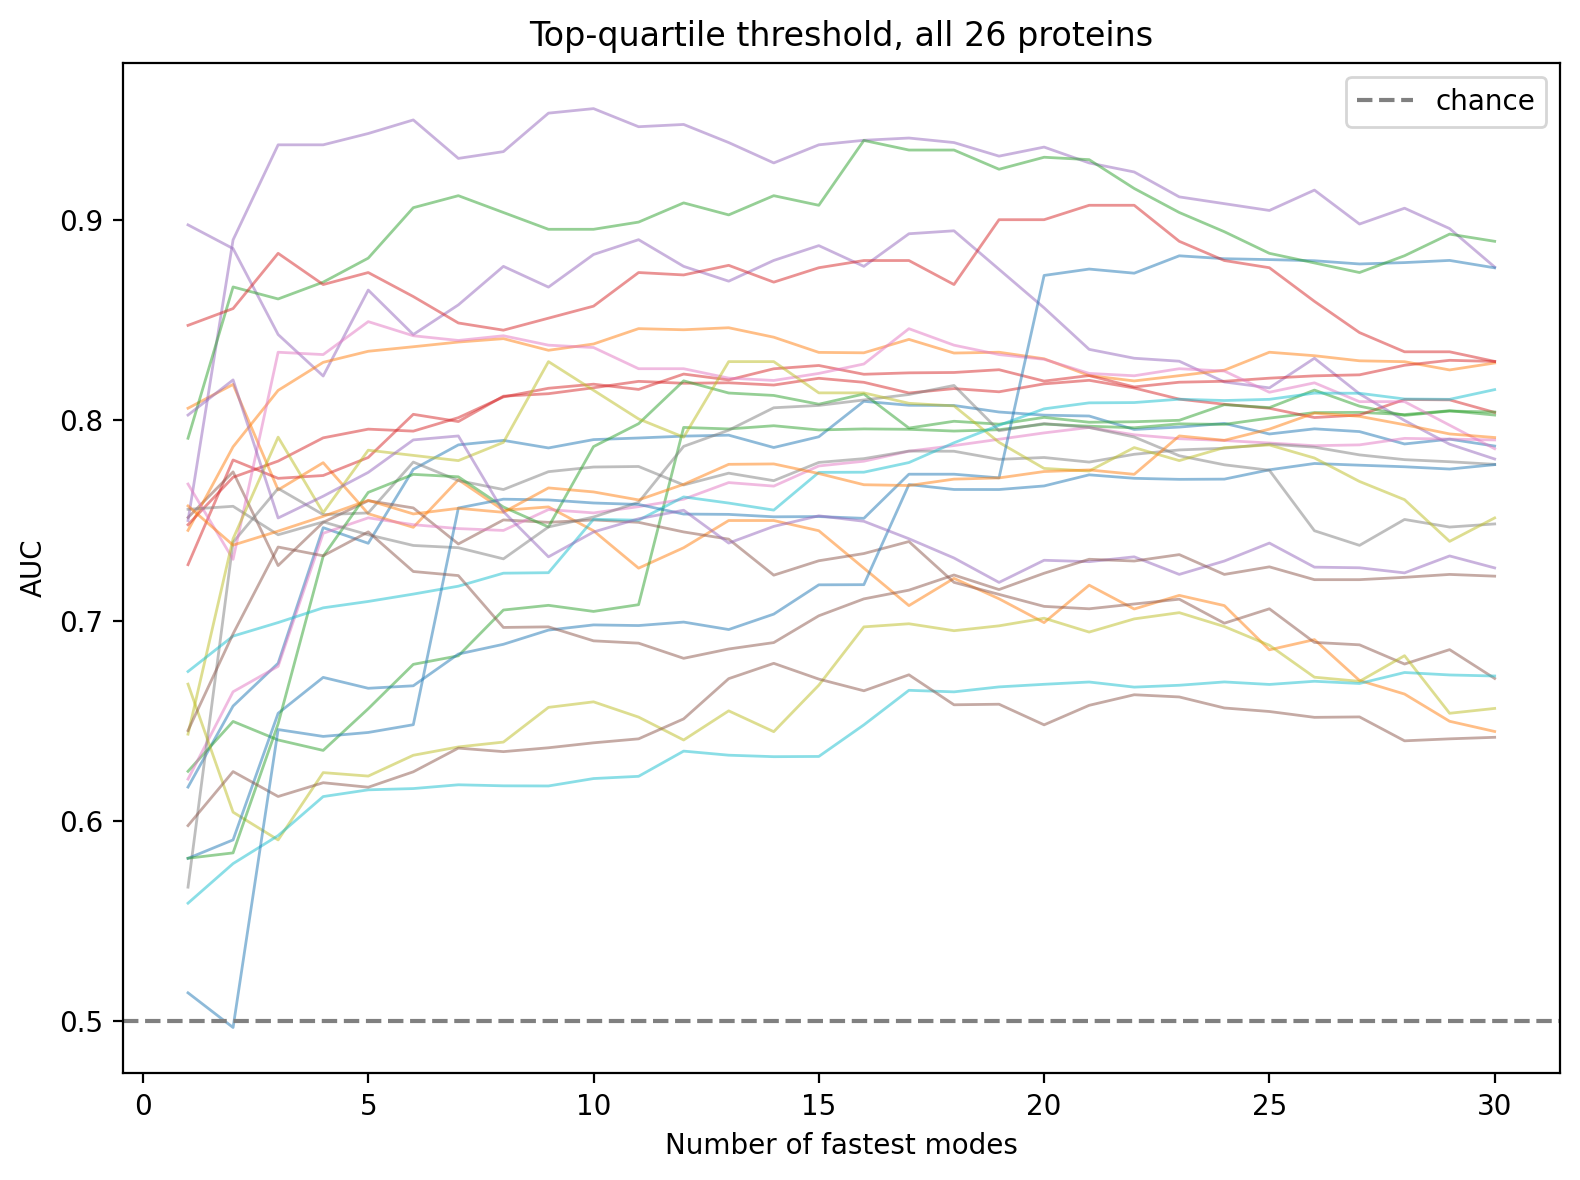

In [101]:
best_per_protein = all_auc_df.loc[all_auc_df.groupby("uniprot_id")["auc"].idxmax()].reset_index(drop=True)
best_per_protein = best_per_protein.merge(family_df[["interpro_superfamily_name"]], left_on="uniprot_id", right_index=True, how="left")
best_per_protein = best_per_protein.merge(
    n_structures_per_protein.rename("n_structures_combined"),
    left_on="uniprot_id", right_index=True, how="left"
)


In [105]:
plt.rcParams.update({'font.size': 14})

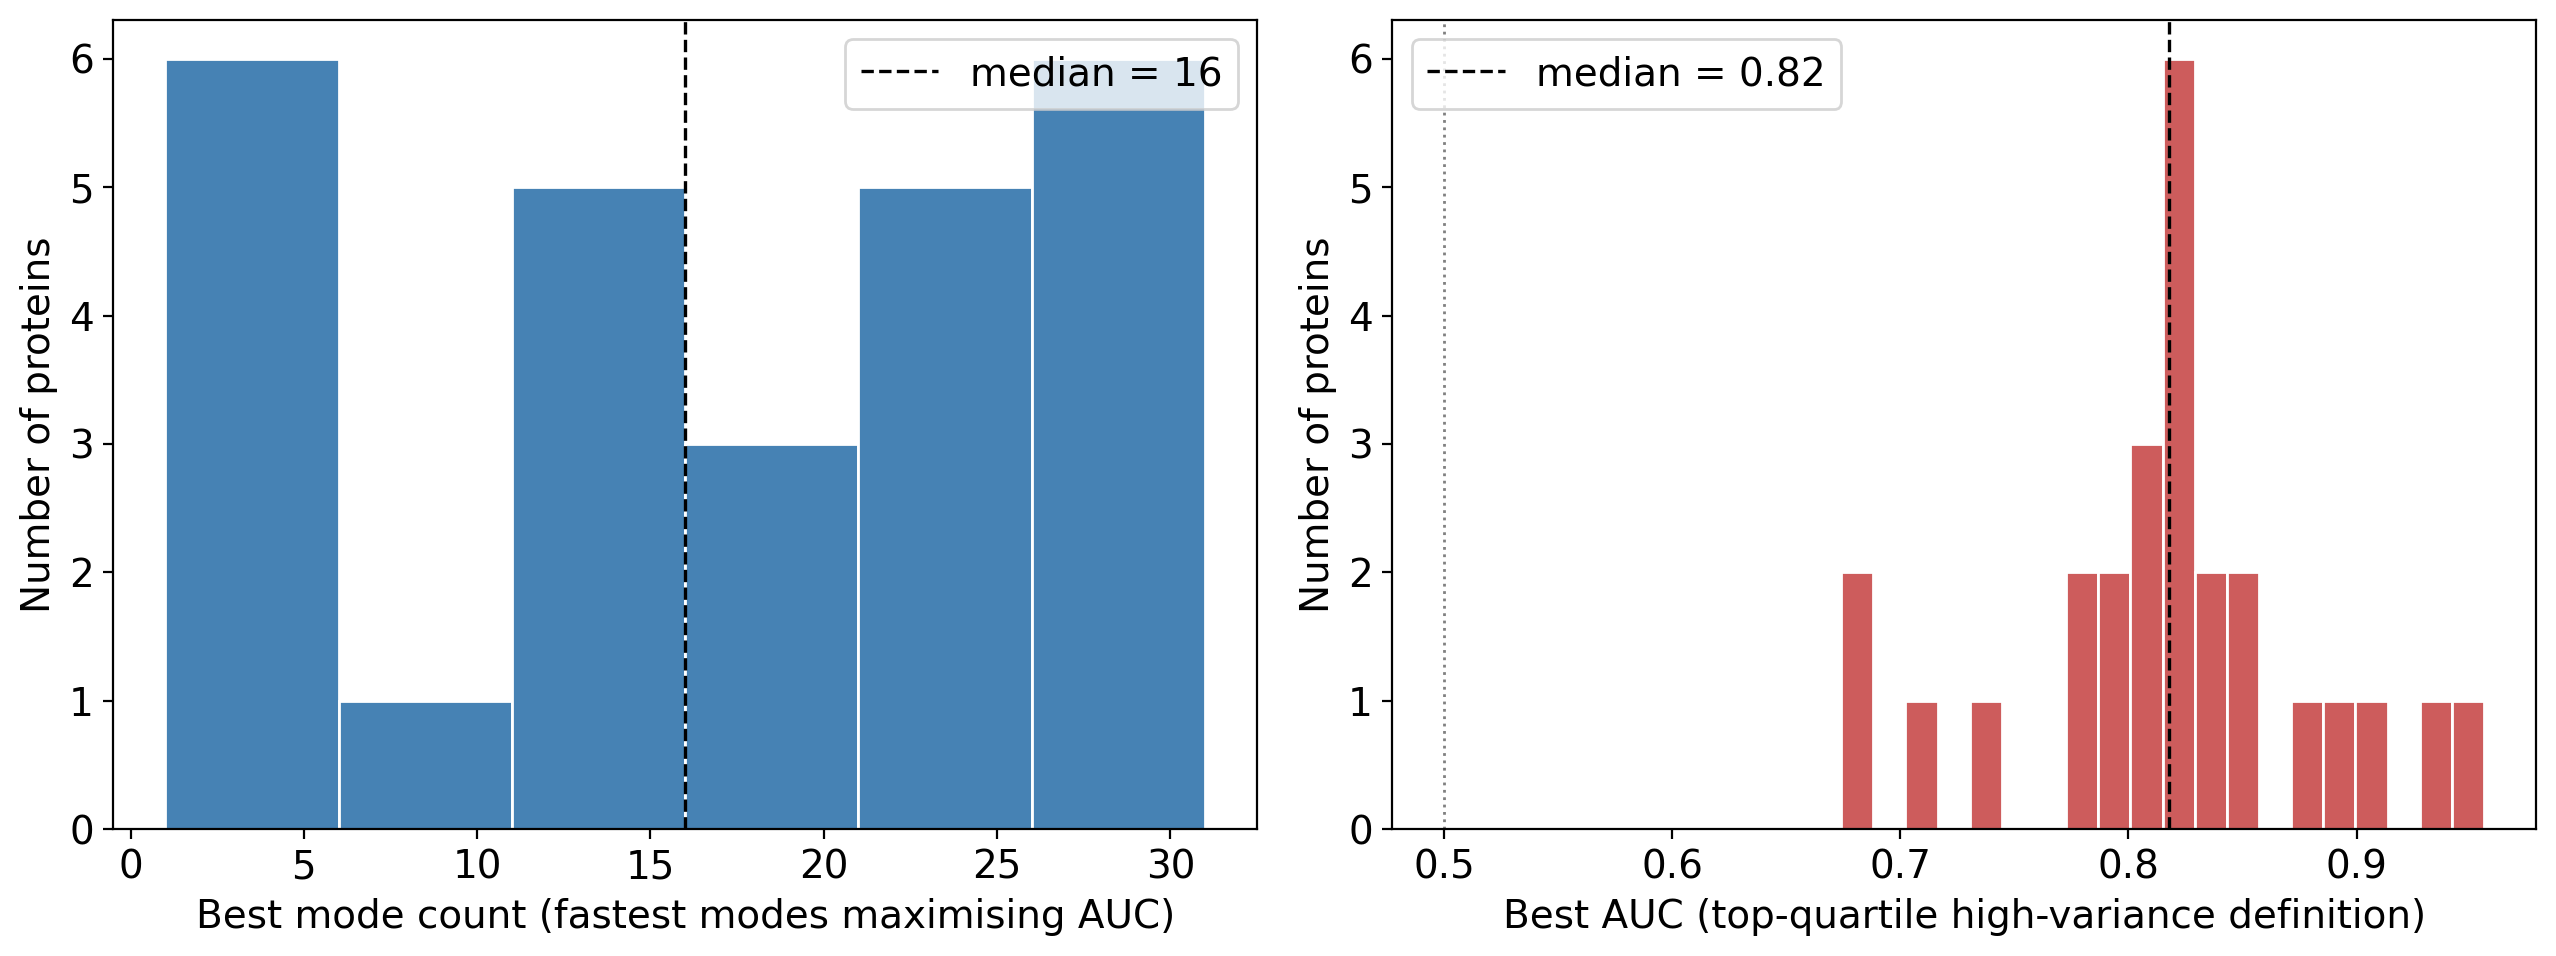

In [107]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=200)

# Histogram of best mode count per protein
axes[0].hist(best_per_protein["mode"], bins=range(1, 32, 5), color="steelblue", edgecolor="white")
axes[0].axvline(best_per_protein["mode"].median(), color="black", linestyle="--", linewidth=1.2,
                 label=f"median = {best_per_protein['mode'].median():.0f}")
axes[0].set_xlabel("Best mode count (fastest modes maximising AUC)")
axes[0].set_ylabel("Number of proteins")
#axes[0].set_title(f"Distribution of best mode count (n={best_per_protein['mode'].notna().sum()} proteins)")
axes[0].legend()

# Histogram of best AUC per protein
axes[1].hist(best_per_protein["auc"], bins=20, color="indianred", edgecolor="white")
axes[1].axvline(best_per_protein["auc"].median(), color="black", linestyle="--", linewidth=1.2,
                 label=f"median = {best_per_protein['auc'].median():.2f}")
axes[1].axvline(0.5, color="gray", linestyle=":", linewidth=1) #, label="chance (AUC=0.5)"
axes[1].set_xlabel("Best AUC (top-quartile high-variance definition)")
axes[1].set_ylabel("Number of proteins")
#axes[1].set_title(f"Distribution of best AUC (n={best_per_protein['auc'].notna().sum()} proteins)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../Figures/Figure_S7.png", dpi=300, bbox_inches="tight")
plt.show()